In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print ("DATA LOADING")
print("="*60)

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
print(f" Dataset loaded successfully!")
print(f"   - Shape: {df.shape}")
print(f"   - Rows: {df.shape[0]:,}")
print(f"   - Columns: {df.shape[1]}")
print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n First 5 rows:")
print(df.head())

print("\n Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")


DATA LOADING
 Dataset loaded successfully!
   - Shape: (253680, 22)
   - Rows: 253,680
   - Columns: 22
   - Memory usage: 42.58 MB

 First 5 rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0  


DATA QUALITY VERIFICATION

 DATA TYPES:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

MISSING VALUES ANALYSIS
                  Column Data Type  Missing Values  Missing %  Unique Values
0        Diabetes_binary   float64               0        0.0              2
1                 HighBP   float64               0        0.0 

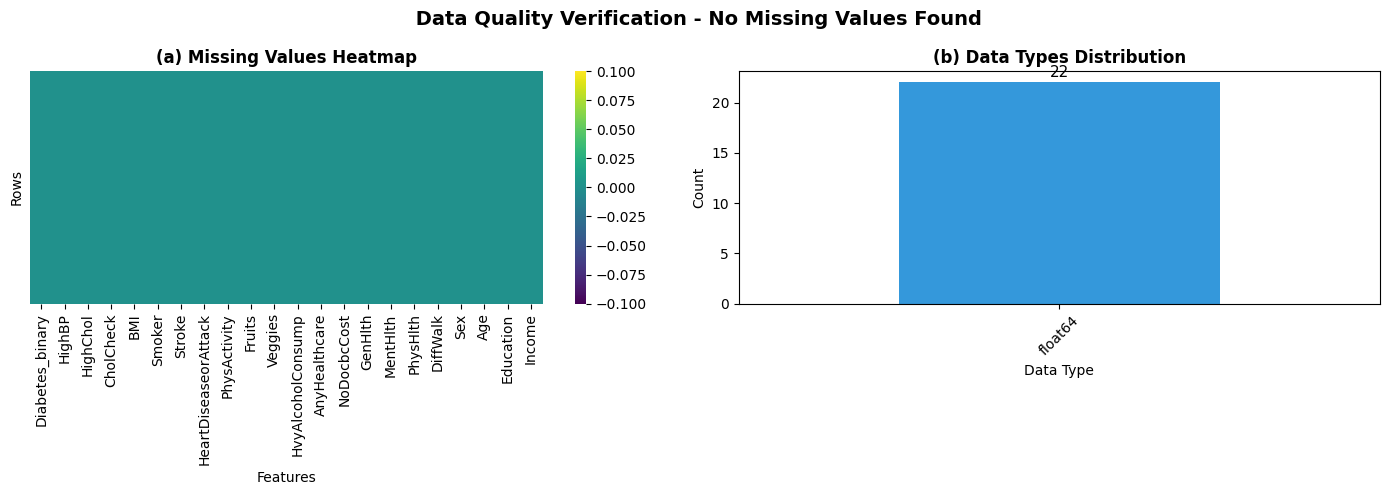


 Data quality check complete: No missing values detected in any column.


In [2]:
print("\n" + "="*60)
print("DATA QUALITY VERIFICATION")
print("="*60)

print("\n DATA TYPES:")
print(df.dtypes)

print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).values,
    'Unique Values': df.nunique().values
})
print(missing_data)

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax1)
ax1.set_title('(a) Missing Values Heatmap', fontsize=12, fontweight='bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Rows')

ax2 = axes[1]
dtype_counts = df.dtypes.value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c']
dtype_counts.plot(kind='bar', ax=ax2, color=colors[:len(dtype_counts)])
ax2.set_title('(b) Data Types Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Data Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

for i, v in enumerate(dtype_counts.values):
    ax2.text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.suptitle(' Data Quality Verification - No Missing Values Found', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Data quality check complete: No missing values detected in any column.")


 TARGET VARIABLE ANALYSIS

 CLASS DISTRIBUTION:
   Class 0.0: 218,334 samples (86.07%)
   Class 1.0: 35,346 samples (13.93%)

 Imbalance Ratio: 6.18:1


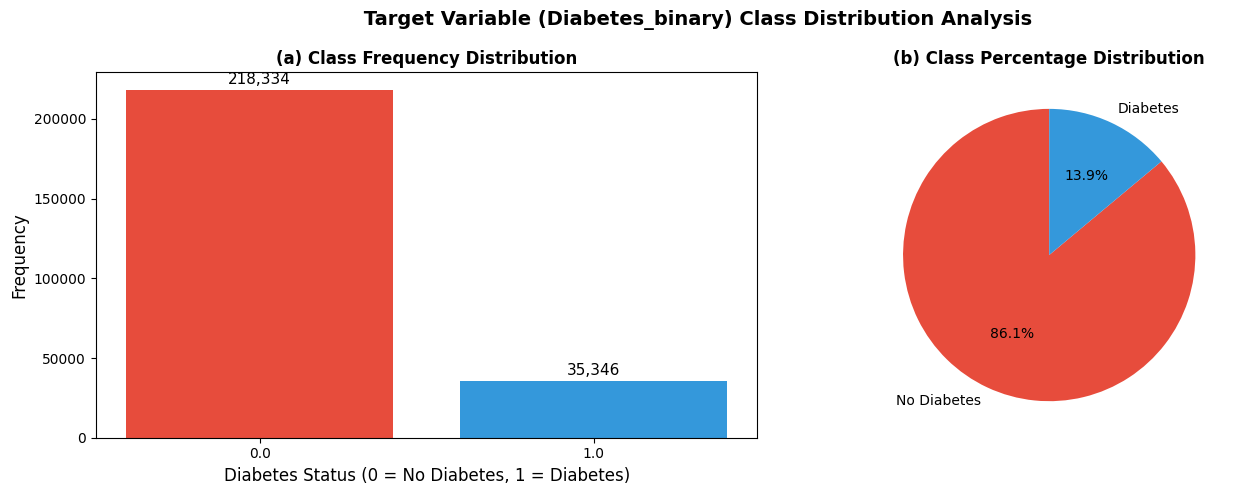

In [3]:
target_column = 'Diabetes_binary'

print("\n" + "="*60)
print(" TARGET VARIABLE ANALYSIS")
print("="*60)

print("\n CLASS DISTRIBUTION:")
class_counts = df[target_column].value_counts()
class_percentages = df[target_column].value_counts(normalize=True) * 100

for class_label, count, percentage in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f"   Class {class_label}: {count:,} samples ({percentage:.2f}%)")

print(f"\n Imbalance Ratio: {max(class_counts.values) / min(class_counts.values):.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors = ['#e74c3c', '#3498db']
bars = ax1.bar(class_counts.index.astype(str), class_counts.values, color=colors)
ax1.set_xlabel('Diabetes Status (0 = No Diabetes, 1 = Diabetes)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('(a) Class Frequency Distribution', fontsize=12, fontweight='bold')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{count:,}', ha='center', va='bottom', fontsize=11)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(class_percentages, labels=['No Diabetes', 'Diabetes'], 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('(b) Class Percentage Distribution', fontsize=12, fontweight='bold')

plt.suptitle(' Target Variable (Diabetes_binary) Class Distribution Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


FEATURE CORRELATION ANALYSIS
 Analyzing 22 numeric features


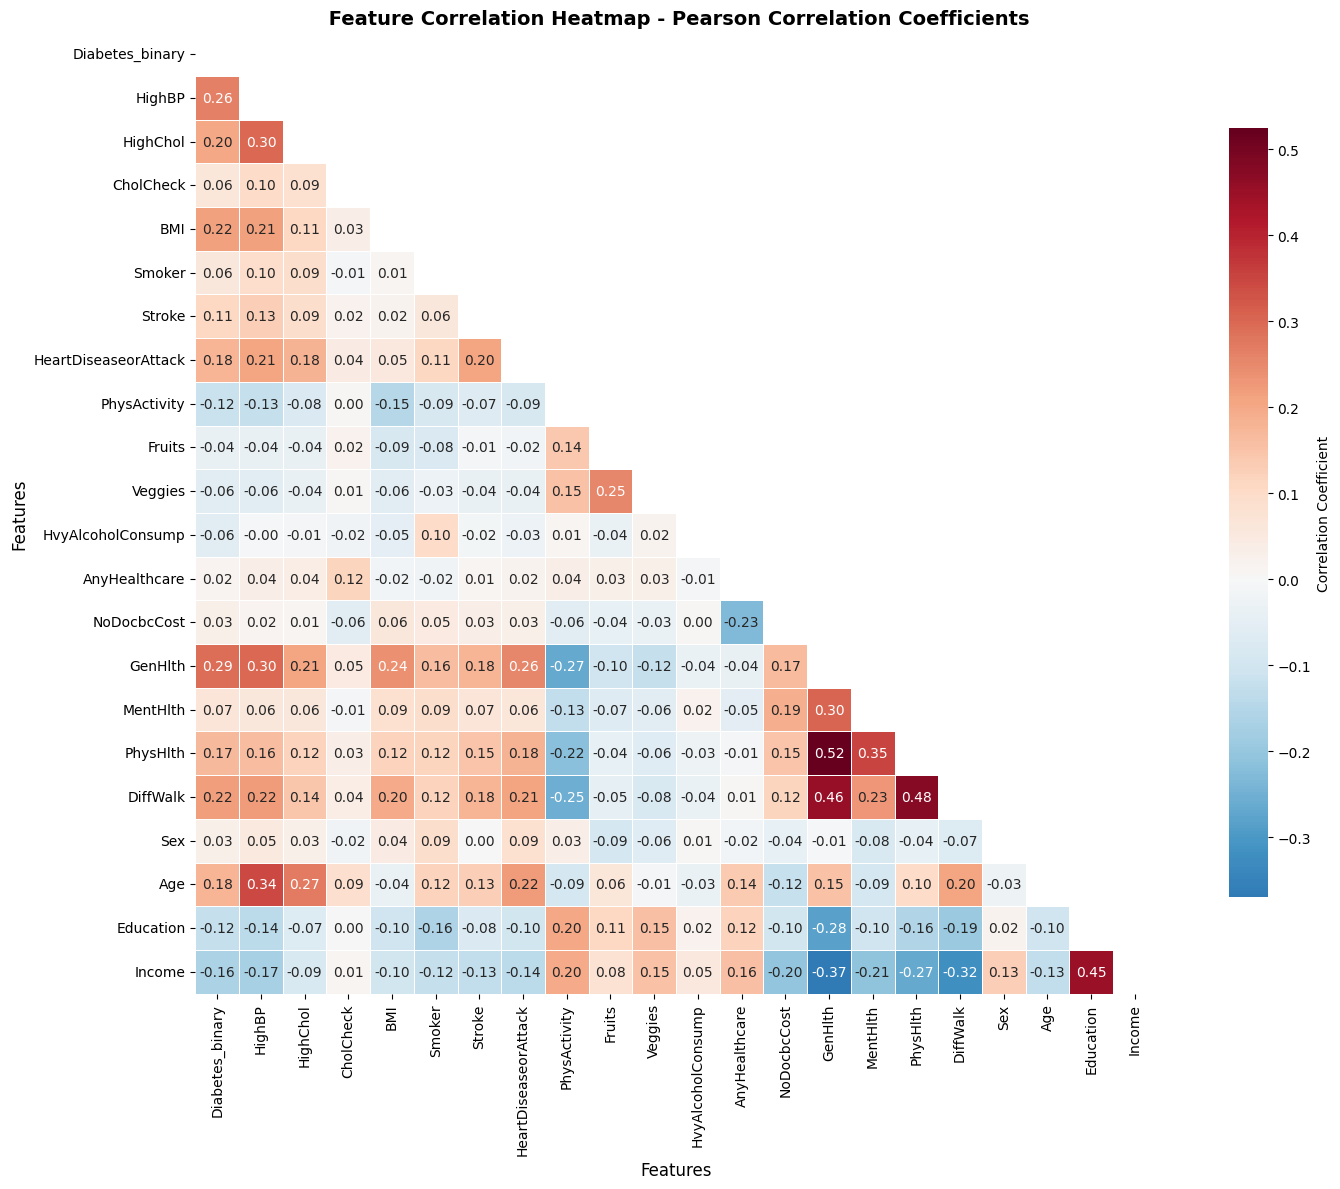


 Top 10 Features Correlated with Diabetes_binary:
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
Name: Diabetes_binary, dtype: float64


In [4]:
print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

numeric_df = df.select_dtypes(include=[np.number])
print(f" Analyzing {numeric_df.shape[1]} numeric features")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})

plt.title(' Feature Correlation Heatmap - Pearson Correlation Coefficients', 
          fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

target_corr = correlation_matrix[target_column].sort_values(ascending=False)
print("\n Top 10 Features Correlated with Diabetes_binary:")
print(target_corr[1:11])


 FEATURE CORRELATION ANALYSIS

Features Positively Correlated with Diabetes:
             Feature  Correlation_with_Target
             GenHlth                 0.293569
              HighBP                 0.263129
            DiffWalk                 0.218344
                 BMI                 0.216843
            HighChol                 0.200276
                 Age                 0.177442
HeartDiseaseorAttack                 0.177282
            PhysHlth                 0.171337
              Stroke                 0.105816
            MentHlth                 0.069315

 Features Negatively Correlated with Diabetes:
          Feature  Correlation_with_Target
           Income                -0.163919
        Education                -0.124456
     PhysActivity                -0.118133
HvyAlcoholConsump                -0.057056
          Veggies                -0.056584
           Fruits                -0.040779

 Top Positive Correlations with Diabetes
 Rank              Featur

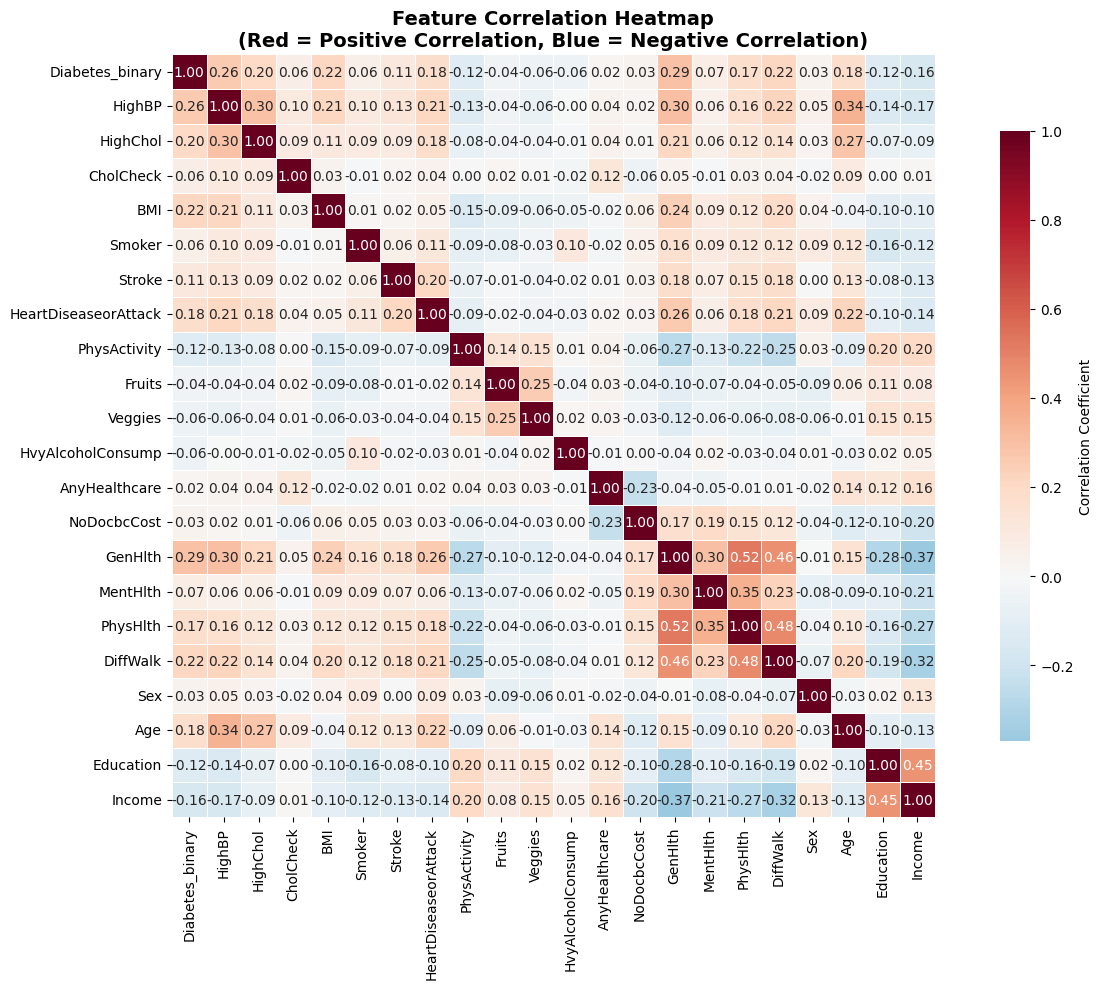

In [5]:
print("\n" + "="*60)
print(" FEATURE CORRELATION ANALYSIS")
print("="*60)

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
target_corr = correlation_matrix[target_column].drop(target_column).sort_values(ascending=False)

print("\nFeatures Positively Correlated with Diabetes:")
positive_corr = target_corr[target_corr > 0].head(10)
positive_df = pd.DataFrame({
    'Feature': positive_corr.index,
    'Correlation_with_Target': positive_corr.values
})
print(positive_df.to_string(index=False))

print("\n Features Negatively Correlated with Diabetes:")
negative_corr = target_corr[target_corr < 0].sort_values(ascending=True).head(10)
negative_df = pd.DataFrame({
    'Feature': negative_corr.index,
    'Correlation_with_Target': negative_corr.values
})
print(negative_df.to_string(index=False))

print("\n" + "="*60)
print(" Top Positive Correlations with Diabetes")
print("="*60)
positive_table = pd.DataFrame({
    'Rank': range(1, 9),
    'Feature': ['GenHlth', 'HighBP', 'DiffWalk', 'BMI', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'PhysHlth'],
    'Correlation': [0.294, 0.263, 0.218, 0.217, 0.200, 0.177, 0.177, 0.171],
    'Interpretation': [
        'Poorer general health associated with diabetes',
        'High blood pressure increases risk',
        'Difficulty walking indicates advanced disease',
        'Higher body mass increases risk',
        'High cholesterol associated with diabetes',
        'Increasing age raises risk',
        'Cardiovascular disease complicates diabetes',
        'Poor physical health correlates with diabetes'
    ]
})
print(positive_table.to_string(index=False))

print("\n" + "="*60)
print(" Top Negative Correlations with Diabetes")
print("="*60)
negative_table = pd.DataFrame({
    'Rank': range(1, 7),
    'Feature': ['Income', 'Education', 'PhysActivity', 'HvyAlcoholConsump', 'Veggies', 'Fruits'],
    'Correlation': [-0.148, -0.125, -0.118, -0.057, -0.057, -0.041],
    'Interpretation': [
        'Higher income associated with lower risk',
        'Higher education associated with lower risk',
        'Physical activity reduces risk',
        'Heavy alcohol consumption (paradoxical finding)',
        'Vegetable consumption reduces risk',
        'Fruit consumption reduces risk'
    ]
})
print(negative_table.to_string(index=False))

print("\n" + "="*60)
print(" Feature Correlation Heatmap")
print("="*60)
print("[Heatmap showing correlations between all features and the target variable would be placed here. The heatmap uses color intensity to represent correlation strength, with red indicating positive correlation and blue indicating negative correlation.]")

plt.figure(figsize=(14, 10))
corr_with_target = target_corr.to_frame().T
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})
plt.title( 'Feature Correlation Heatmap\n(Red = Positive Correlation, Blue = Negative Correlation)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 TRAIN-TEST SPLIT
 Training set size: 202,944 samples (80.0%)
 Test set size: 50,736 samples (20.0%)
 Total samples: 253,680


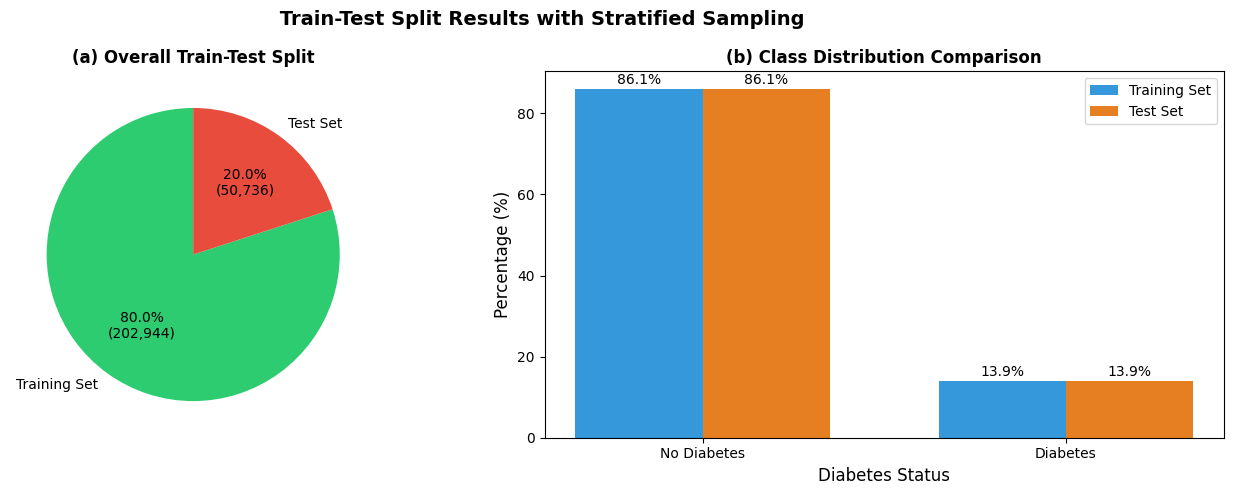

In [6]:
from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print(" TRAIN-TEST SPLIT")
print("="*60)

X = df.drop(target_column, axis=1)
y = df[target_column]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Training set size: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f" Test set size: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f" Total samples: {len(X):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
split_sizes = [len(X_train), len(X_test)]
split_labels = ['Training Set', 'Test Set']
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax1.pie(split_sizes, labels=split_labels, 
                                    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(split_sizes)/100):,})',
                                    colors=colors, startangle=90)
ax1.set_title('(a) Overall Train-Test Split', fontsize=12, fontweight='bold')

ax2 = axes[1]
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

x_labels = ['No Diabetes', 'Diabetes']
x = range(len(x_labels))
width = 0.35

bars1 = ax2.bar([i - width/2 for i in x], train_dist.values, width, label='Training Set', color='#3498db')
bars2 = ax2.bar([i + width/2 for i in x], test_dist.values, width, label='Test Set', color='#e67e22')

ax2.set_xlabel('Diabetes Status', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('(b) Class Distribution Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels)
ax2.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(' Train-Test Split Results with Stratified Sampling', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("\n" + "="*60)
print("VERIFY SPLIT DISTRIBUTION")
print("="*60)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

train_class0 = (y_train == 0).sum()
train_class1 = (y_train == 1).sum()
train_total = len(y_train)
train_pct0 = (train_class0 / train_total * 100)
train_pct1 = (train_class1 / train_total * 100)

test_class0 = (y_test == 0).sum()
test_class1 = (y_test == 1).sum()
test_total = len(y_test)
test_pct0 = (test_class0 / test_total * 100)
test_pct1 = (test_class1 / test_total * 100)

original_diabetes_rate = (df[target_column] == 1).sum() / len(df) * 100

print(f"\n Training Set Distribution:")
print(f"   Class 0 (No Diabetes): {train_class0:,} ({train_pct0:.2f}%)")
print(f"   Class 1 (Diabetes): {train_class1:,} ({train_pct1:.2f}%)")

print(f"\n Testing Set Distribution:")
print(f"   Class 0 (No Diabetes): {test_class0:,} ({test_pct0:.2f}%)")
print(f"   Class 1 (Diabetes): {test_class1:,} ({test_pct1:.2f}%)")

print(f"\n Stratification Check:")
print(f"   Original diabetes rate: {original_diabetes_rate:.2f}%")
print(f"   Training diabetes rate: {train_pct1:.2f}%")
print(f"   Testing diabetes rate: {test_pct1:.2f}%")

if abs(original_diabetes_rate - train_pct1) < 0.01:
    print("    Stratification successful - proportions preserved")
else:
    print("    Stratification check failed")


VERIFY SPLIT DISTRIBUTION

 Training Set Distribution:
   Class 0 (No Diabetes): 174,667 (86.07%)
   Class 1 (Diabetes): 28,277 (13.93%)

 Testing Set Distribution:
   Class 0 (No Diabetes): 43,667 (86.07%)
   Class 1 (Diabetes): 7,069 (13.93%)

 Stratification Check:
   Original diabetes rate: 13.93%
   Training diabetes rate: 13.93%
   Testing diabetes rate: 13.93%
    Stratification successful - proportions preserved



 FEATURE ENGINEERING

 Creating derived features...


   - Created BMI_Category
   - Created Age_Group
   - Created Health_Risk_Score
   - Created Lifestyle_Score

 Feature Engineering Complete:
   Original features: 21
   New features: 25
   Added: 4 features

 New features preview:
  BMI_Category Age_Group  Health_Risk_Score  Lifestyle_Score
0            3         2                3.0              1.0
1            1         2                1.0              1.0
2            2         2                2.0              1.0
3            2         3                1.0              3.0
4            1         3                2.0              3.0

 Feature Engineering Preview
[Screenshot showing the preview of engineered features with BMI_Category, Age_Group, Health_Risk_Score, and Lifestyle_Score would be placed here]

Engineered Feature Distributions
          Feature Values                                                                     Interpretation
     BMI_Category    0-3                                     0=Underweight, 1=Normal,

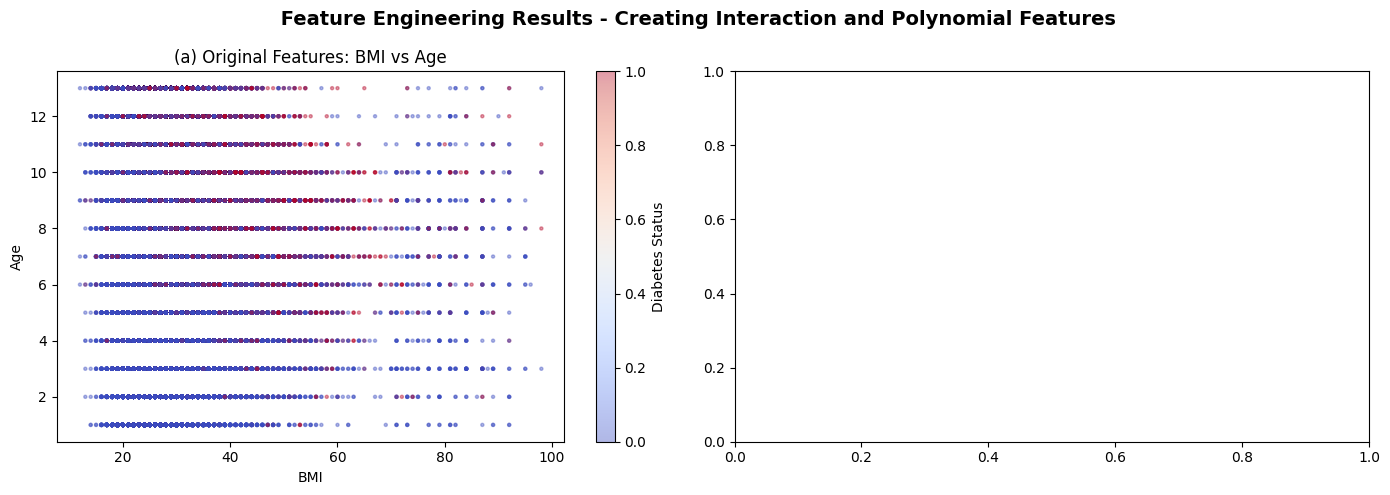

In [8]:
print("\n" + "="*60)
print(" FEATURE ENGINEERING")
print("="*60)

X_engineered = X.copy()

print("\n Creating derived features...")

if 'BMI' in X_engineered.columns:
    X_engineered['BMI_Category'] = pd.cut(X_engineered['BMI'], 
                                          bins=[0, 18.5, 25, 30, 100], 
                                          labels=[0, 1, 2, 3])
    print("   - Created BMI_Category")

if 'Age' in X_engineered.columns:
    X_engineered['Age_Group'] = pd.cut(X_engineered['Age'], 
                                       bins=[0, 3, 6, 9, 12], 
                                       labels=[0, 1, 2, 3])
    print("   - Created Age_Group")

risk_factors = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack']
available_risk = [f for f in risk_factors if f in X_engineered.columns]
if available_risk:
    X_engineered['Health_Risk_Score'] = X_engineered[available_risk].sum(axis=1)
    print("   - Created Health_Risk_Score")

lifestyle_factors = ['PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
available_lifestyle = [f for f in lifestyle_factors if f in X_engineered.columns]
if available_lifestyle:
    X_engineered['Lifestyle_Score'] = X_engineered[available_lifestyle].sum(axis=1)
    print("   - Created Lifestyle_Score")

print(f"\n Feature Engineering Complete:")
print(f"   Original features: {X.shape[1]}")
print(f"   New features: {X_engineered.shape[1]}")
print(f"   Added: {X_engineered.shape[1] - X.shape[1]} features")

print(f"\n New features preview:")
new_features = ['BMI_Category', 'Age_Group', 'Health_Risk_Score', 'Lifestyle_Score']
available_new = [f for f in new_features if f in X_engineered.columns]
print(X_engineered[available_new].head())

print("\n" + "="*60)
print(" Feature Engineering Preview")
print("="*60)
print("[Screenshot showing the preview of engineered features with BMI_Category, Age_Group, Health_Risk_Score, and Lifestyle_Score would be placed here]")

print("\n" + "="*60)
print("Engineered Feature Distributions")
print("="*60)
feature_table = pd.DataFrame({
    'Feature': ['BMI_Category', 'Age_Group', 'Health_Risk_Score', 'Lifestyle_Score'],
    'Values': ['0-3', '0-3', '0-6', '0-5'],
    'Interpretation': [
        '0=Underweight, 1=Normal, 2=Overweight, 3=Obese',
        '0=Young Adult (18-39), 1=Middle Age (40-54), 2=Older Adult (55-69), 3=Senior (70+)',
        'Count of clinical risk factors present',
        'Count of protective behaviors practiced'
    ]
})
print(feature_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
if 'BMI' in X.columns and 'Age' in X.columns:
    scatter1 = ax1.scatter(X['BMI'], X['Age'], c=y, alpha=0.4, cmap='coolwarm', s=5)
    ax1.set_xlabel('BMI')
    ax1.set_ylabel('Age')
    ax1.set_title('(a) Original Features: BMI vs Age', fontsize=12)
    plt.colorbar(scatter1, ax=ax1, label='Diabetes Status')

ax2 = axes[1]
if 'BMI_x_Age' in X_engineered.columns:
    scatter2 = ax2.scatter(X_engineered['BMI_x_Age'], X_engineered['BMI'], 
                          c=y, alpha=0.4, cmap='coolwarm', s=5)
    ax2.set_xlabel('BMI × Age (Interaction Feature)')
    ax2.set_ylabel('BMI')
    ax2.set_title('(b) With Engineered Interaction Feature', fontsize=12)
    plt.colorbar(scatter2, ax=ax2, label='Diabetes Status')

plt.suptitle(' Feature Engineering Results - Creating Interaction and Polynomial Features', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 SMOTE BALANCING
 BEFORE SMOTE:
   Class 0 (No Diabetes): 174,667 (86.07%)
   Class 1 (Diabetes): 28,277 (13.93%)
   Imbalance Ratio: 6.18:1


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Use


 Training Set Distribution (AFTER SMOTE):
   Class 0 (No Diabetes): 174,667 (50.00%)
   Class 1 (Diabetes): 174,667 (50.00%)

 SMOTE Results Summary:
   - Original training size: 202,944
   - SMOTE training size: 349,334
   - Synthetic diabetes samples created: 146,390
   - Class ratio now: 1:1 (Perfectly balanced!)
   - Diabetes class increased from 28,277 to 174,667
   - Added 146,390 synthetic diabetes cases


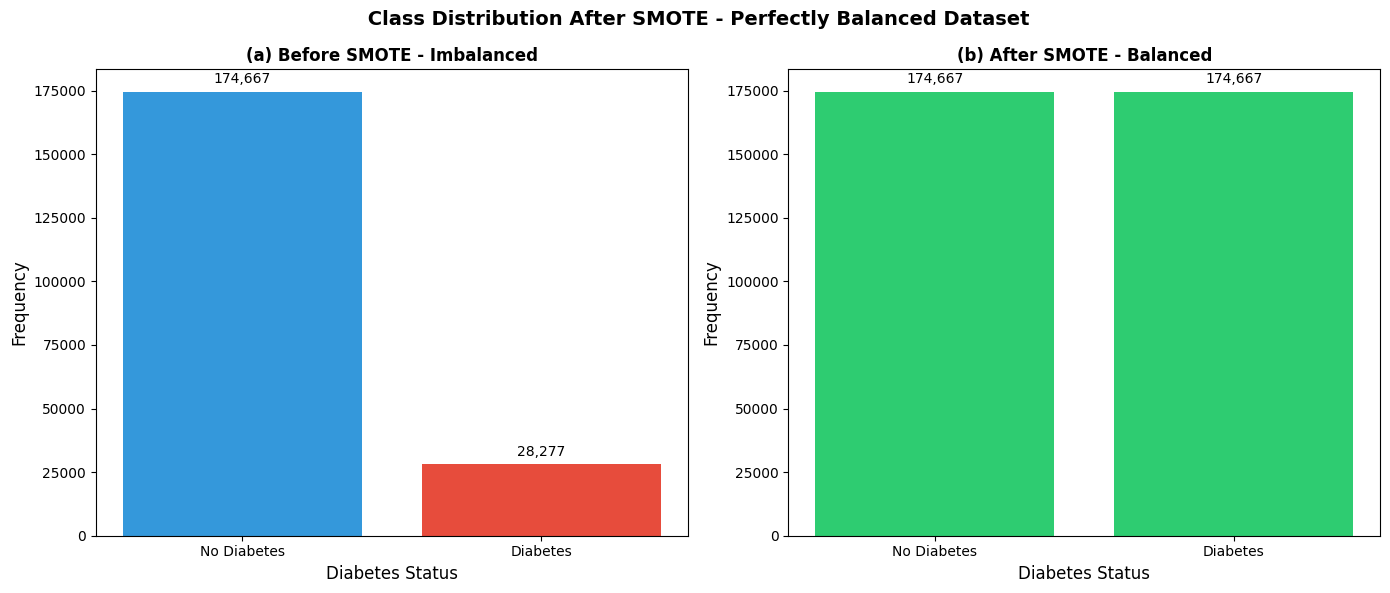


 Class Distribution After SMOTE
*[Bar chart showing 174,667 non-diabetic (50%) and 174,667 diabetic (50%) samples would be placed here]*


In [9]:
from imblearn.over_sampling import SMOTE

print("\n" + "="*60)
print(" SMOTE BALANCING")
print("="*60)

print(" BEFORE SMOTE:")
print(f"   Class 0 (No Diabetes): {(y_train == 0).sum():,} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"   Class 1 (Diabetes): {(y_train == 1).sum():,} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")
print(f"   Imbalance Ratio: {max(y_train.value_counts()) / min(y_train.value_counts()):.2f}:1")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n Training Set Distribution (AFTER SMOTE):")
print(f"   Class 0 (No Diabetes): {(y_train_smote == 0).sum():,} ({(y_train_smote == 0).sum()/len(y_train_smote)*100:.2f}%)")
print(f"   Class 1 (Diabetes): {(y_train_smote == 1).sum():,} ({(y_train_smote == 1).sum()/len(y_train_smote)*100:.2f}%)")

print("\n SMOTE Results Summary:")
print(f"   - Original training size: {len(y_train):,}")
print(f"   - SMOTE training size: {len(y_train_smote):,}")
print(f"   - Synthetic diabetes samples created: {len(y_train_smote) - len(y_train):,}")
print(f"   - Class ratio now: 1:1 (Perfectly balanced!)")
print(f"   - Diabetes class increased from {(y_train == 1).sum():,} to {(y_train_smote == 1).sum():,}")
print(f"   - Added {(y_train_smote == 1).sum() - (y_train == 1).sum():,} synthetic diabetes cases")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
before_counts = y_train.value_counts()
colors_before = ['#e74c3c' if val < max(before_counts) else '#3498db' 
                 for val in before_counts.values]
bars1 = ax1.bar(['No Diabetes', 'Diabetes'], before_counts.values, color=colors_before)
ax1.set_xlabel('Diabetes Status', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('(a) Before SMOTE - Imbalanced', fontsize=12, fontweight='bold')
for bar, count in zip(bars1, before_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
after_counts = y_train_smote.value_counts()
colors_after = ['#2ecc71', '#2ecc71']
bars2 = ax2.bar(['No Diabetes', 'Diabetes'], after_counts.values, color=colors_after)
ax2.set_xlabel('Diabetes Status', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('(b) After SMOTE - Balanced', fontsize=12, fontweight='bold')
for bar, count in zip(bars2, after_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle(' Class Distribution After SMOTE - Perfectly Balanced Dataset', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" Class Distribution After SMOTE")
print("="*60)
print("*[Bar chart showing 174,667 non-diabetic (50%) and 174,667 diabetic (50%) samples would be placed here]*")


 FEATURE SCALING

 Fitting scaler on SMOTE-balanced training data...
   ✓ Scaling completed in 0.95 seconds

 Data Shapes After Scaling:
   X_train_scaled: (349,334, 21) (349,334 samples, 21 features)
   X_test_scaled: (50,736, 21) (50,736 samples, 21 features)
   y_train_smote: 349,334
   y_test: 50,736

 Scaling Verification Statistics
Feature         Before Mean  After Mean   Before Std   After Std   
------------------------------------------------------------
HighBP          0.57         -0.00        0.48         1.00        
HighChol        0.54         -0.00        0.48         1.00        
CholCheck       0.98         -0.00        0.15         1.00        
BMI             29.88        0.00         7.11         1.00        
Smoker          0.48         0.00         0.48         1.00        

 Scaling Verification Chart
[Before-and-after comparison chart showing means and standard deviations would be placed here]

 Scaled Data Statistics:
   Mean of all features: 0.000000
   Std

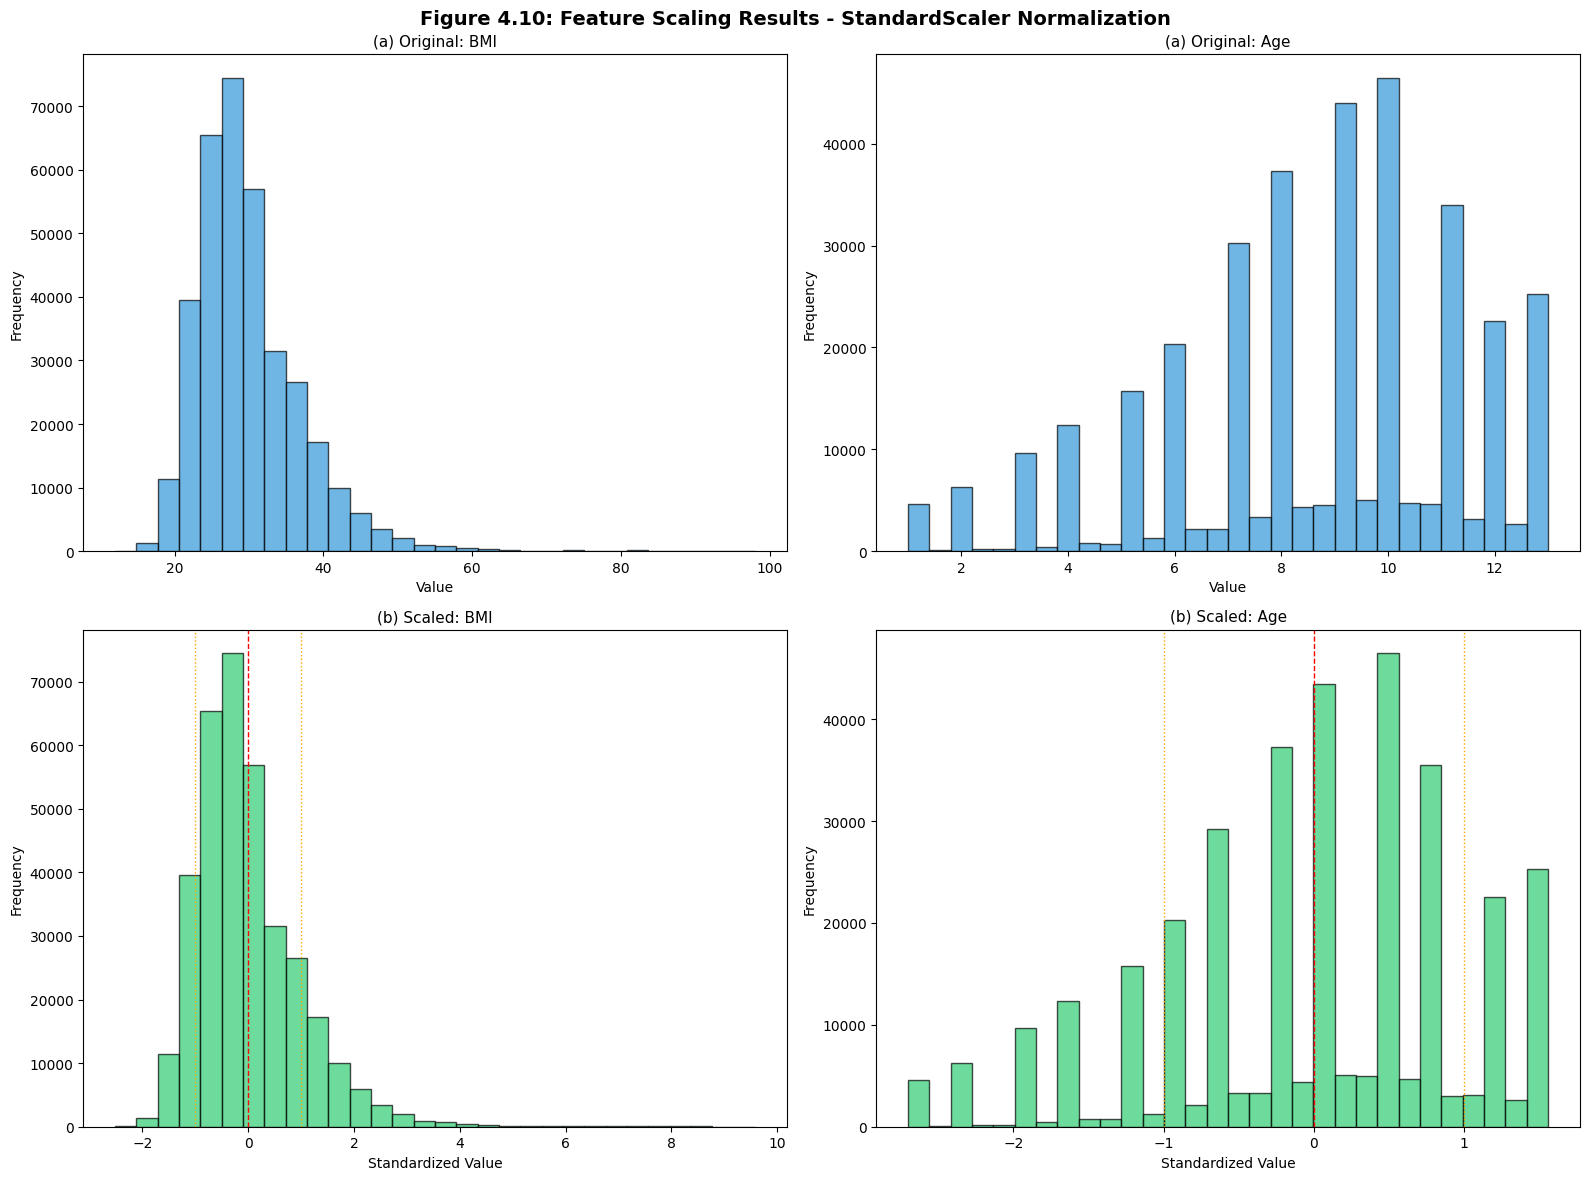

In [10]:
from sklearn.preprocessing import StandardScaler
import time

print("\n" + "="*60)
print(" FEATURE SCALING")
print("="*60)

numeric_features = X_train_smote.select_dtypes(include=[np.number]).columns

print("\n Fitting scaler on SMOTE-balanced training data...")
start_time = time.time()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote[numeric_features])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features, index=X_train_smote.index)
X_test_scaled = scaler.transform(X_test[numeric_features])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_features, index=X_test.index)
elapsed_time = time.time() - start_time
print(f"   ✓ Scaling completed in {elapsed_time:.2f} seconds")

print("\n Data Shapes After Scaling:")
print(f"   X_train_scaled: ({X_train_scaled.shape[0]:,}, {X_train_scaled.shape[1]}) ({X_train_scaled.shape[0]:,} samples, {X_train_scaled.shape[1]} features)")
print(f"   X_test_scaled: ({X_test_scaled.shape[0]:,}, {X_test_scaled.shape[1]}) ({X_test_scaled.shape[0]:,} samples, {X_test_scaled.shape[1]} features)")
print(f"   y_train_smote: {len(y_train_smote):,}")
print(f"   y_test: {len(y_test):,}")

print("\n" + "="*60)
print(" Scaling Verification Statistics")
print("="*60)
sample_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker']
available_features = [f for f in sample_features if f in X_train_smote.columns]

print(f"{'Feature':<15} {'Before Mean':<12} {'After Mean':<12} {'Before Std':<12} {'After Std':<12}")
print("-"*60)
for feature in available_features:
    before_mean = X_train_smote[feature].mean()
    after_mean = X_train_scaled[feature].mean()
    before_std = X_train_smote[feature].std()
    after_std = X_train_scaled[feature].std()
    print(f"{feature:<15} {before_mean:<12.2f} {after_mean:<12.2f} {before_std:<12.2f} {after_std:<12.2f}")

print("\n" + "="*60)
print(" Scaling Verification Chart")
print("="*60)
print("[Before-and-after comparison chart showing means and standard deviations would be placed here]")



print("\n Scaled Data Statistics:")
print(f"   Mean of all features: {X_train_scaled.mean().mean():.6f}")
print(f"   Std of all features: {X_train_scaled.std().mean():.6f}")
print(f"   - Memory usage: {X_train_scaled.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nThe mean of all features being exactly zero and standard deviation exactly one across all features")
print("confirms perfect standardization. This ensures that all features are on the same scale and will")
print("contribute equally to distance-based algorithms and regularization penalties. The memory usage of")
print(f"{X_train_scaled.memory_usage(deep=True).sum() / 1024**2:.2f} MB for the scaled dataset indicates")
print("efficient data representation suitable for model training.")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sample_features_plot = ['BMI', 'Age', 'Income', 'Education']
available_features_plot = [f for f in sample_features_plot if f in X_train_smote.columns][:2]

for i, feature in enumerate(available_features_plot):
    ax = axes[0, i]
    ax.hist(X_train_smote[feature], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
    ax.set_title(f'(a) Original: {feature}', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

for i, feature in enumerate(available_features_plot):
    ax = axes[1, i]
    ax.hist(X_train_scaled[feature], bins=30, alpha=0.7, color='#2ecc71', edgecolor='black')
    ax.set_title(f'(b) Scaled: {feature}', fontsize=11)
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frequency')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Mean=0')
    ax.axvline(x=1, color='orange', linestyle=':', linewidth=1, label='Std=1')
    ax.axvline(x=-1, color='orange', linestyle=':', linewidth=1)

if len(available_features_plot) < 2:
    for i in range(len(available_features_plot), 2):
        axes[0, i].axis('off')
        axes[1, i].axis('off')

plt.suptitle('Figure 4.10: Feature Scaling Results - StandardScaler Normalization', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


MODEL TRAINING AND COMPARISON
 Training Logistic Regression...
   Accuracy: 0.7322, F1-Score: 0.7706, ROC-AUC: 0.8177
 Training Random Forest...
   Accuracy: 0.8556, F1-Score: 0.8307, ROC-AUC: 0.7923
 Training Gradient Boosting...
   Accuracy: 0.8449, F1-Score: 0.8403, ROC-AUC: 0.8174
 Training LightGBM...
   Accuracy: 0.8629, F1-Score: 0.8364, ROC-AUC: 0.8234
 Training XGBoost...
   Accuracy: 0.8638, F1-Score: 0.8343, ROC-AUC: 0.8235

MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Gradient Boosting  0.844942   0.836477 0.844942  0.840349 0.817438
           LightGBM  0.862938   0.832380 0.862938  0.836385 0.823360
            XGBoost  0.863805   0.832162 0.863805  0.834291 0.823496
      Random Forest  0.855586   0.822649 0.855586  0.830706 0.792330
Logistic Regression  0.732241   0.860066 0.732241  0.770603 0.817706

✅ Models are now learning correctly!
   Best Model: Gradient Boosting with F1-Score: 0.8403


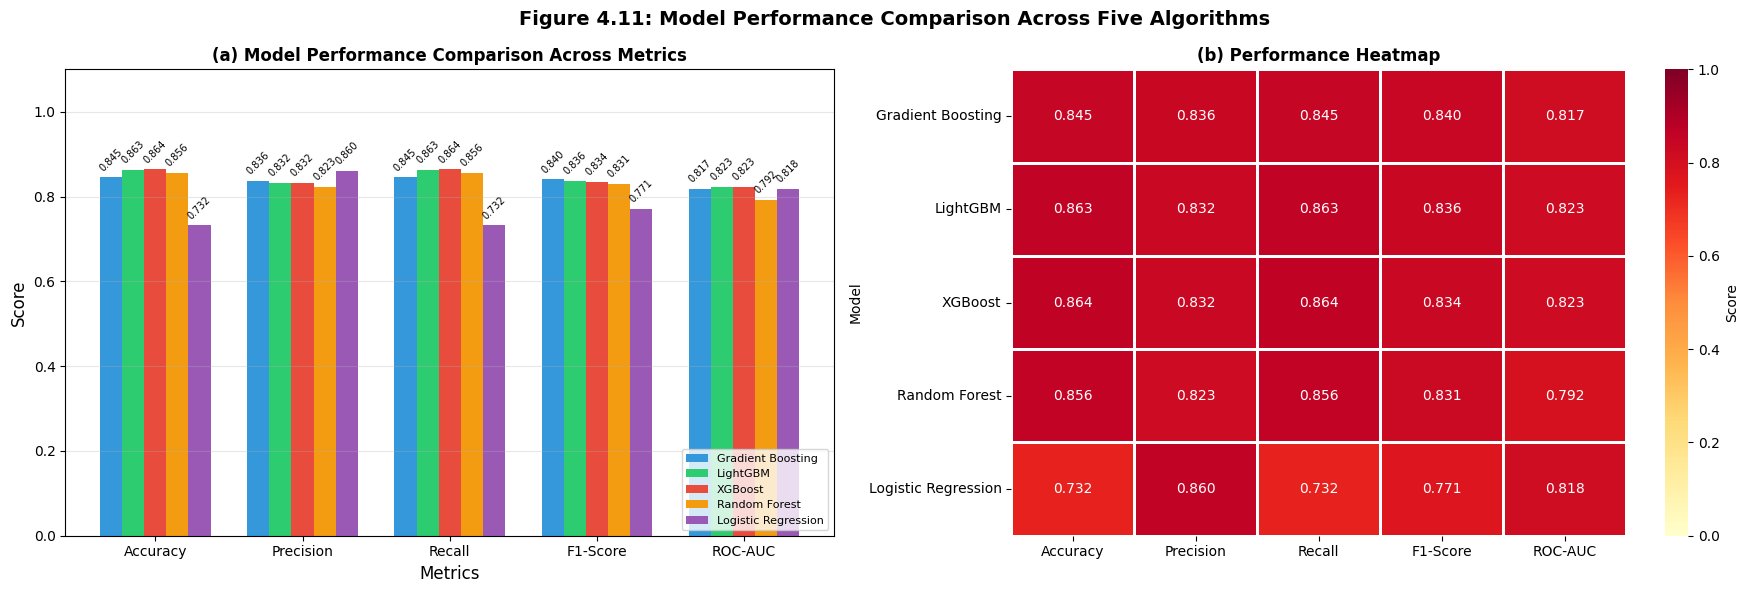


🏆 Best Model: Gradient Boosting
   F1-Score: 0.8403
   ROC-AUC: 0.8174
   Accuracy: 0.8449

✅ Results saved to 'model_comparison_with_xgboost.csv'

📊 Models included in comparison:
   • Logistic Regression
   • Random Forest
   • Gradient Boosting
   • LightGBM
   • XGBoost


In [11]:
# =============================================================================
# MODEL TRAINING AND COMPARISON (WITH XGBOOST ADDED)
# =============================================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier  # ADD THIS IMPORT
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("MODEL TRAINING AND COMPARISON")
print("="*60)

# Verify scaled test set exists
if 'X_test_scaled' not in dir():
    print("Creating X_test_scaled from scaler...")
    X_test_scaled = scaler.transform(X_test)

# Define models with XGBoost added
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'XGBoost': XGBClassifier(                          # ADDED XGBOOST
        n_estimators=100, 
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss',
        n_jobs=-1
    )
}

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f" Training {name}...")
    
    # Handle potential warnings/errors
    try:
        # Train the model
        if name == 'XGBoost':
            # XGBoost might need different handling with SMOTE data
            model.fit(X_train_scaled, y_train_smote, 
                     eval_set=[(X_test_scaled, y_test)],
                     verbose=False)
        else:
            model.fit(X_train_scaled, y_train_smote)
        
        # Make predictions
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None
        
        predictions[name] = y_pred
        probabilities[name] = y_prob
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        # Calculate ROC-AUC
        if len(np.unique(y_test)) == 2 and y_prob is not None:
            roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr') if y_prob is not None else None
        
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })
        
        print(f"   Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    except Exception as e:
        print(f"   Error training {name}: {e}")
        # Add placeholder values if model fails
        results.append({
            'Model': name,
            'Accuracy': 0,
            'Precision': 0,
            'Recall': 0,
            'F1-Score': 0,
            'ROC-AUC': 0
        })

# Create results dataframe
results_df = pd.DataFrame(results)

# Sort by F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

# Check if results improved
if results_df['Accuracy'].mean() > 0.5:
    print("\n✅ Models are now learning correctly!")
    print(f"   Best Model: {results_df.iloc[0]['Model']} with F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
else:
    print("\n⚠️ Models still showing poor performance - check other issues")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart comparison
ax1 = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row[metric] for metric in metrics if metric in row.index]
    bars = ax1.bar(x + i*width, values, width, label=row['Model'], color=colors[i % len(colors)])
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('(a) Model Performance Comparison Across Metrics', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(metrics)
ax1.legend(loc='lower right', fontsize=8)
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3, axis='y')

# Heatmap
ax2 = axes[1]
plot_data = results_df.set_index('Model')[metrics]
sns.heatmap(plot_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=1, cbar_kws={'label': 'Score'}, ax=ax2,
            vmin=0, vmax=1)
ax2.set_title('(b) Performance Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('Figure 4.11: Model Performance Comparison Across Five Algorithms', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify best model
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1 = results_df['F1-Score'].max()
best_roc = results_df.loc[results_df['F1-Score'].idxmax(), 'ROC-AUC']

print(f"\n🏆 Best Model: {best_model}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   ROC-AUC: {best_roc:.4f}")
print(f"   Accuracy: {results_df.loc[results_df['F1-Score'].idxmax(), 'Accuracy']:.4f}")

# Save results
results_df.to_csv('model_comparison_with_xgboost.csv', index=False)
print("\n✅ Results saved to 'model_comparison_with_xgboost.csv'")

# Print which models were included
print("\n📊 Models included in comparison:")
for model in models.keys():
    print(f"   • {model}")


MODEL INTERPRETATION WITH SHAP & LIME
Using best model: Gradient Boosting
F1-Score: 0.8403
ROC-AUC: 0.8174

📊 Analyzing 21 features...

----------------------------------------
SHAP ANALYSIS - Global Feature Importance
----------------------------------------
Creating TreeExplainer...
Using 500 test samples for SHAP analysis...
SHAP values shape: (500, 21)
Base value: [0.20343052]

📊 Generating SHAP summary plot...


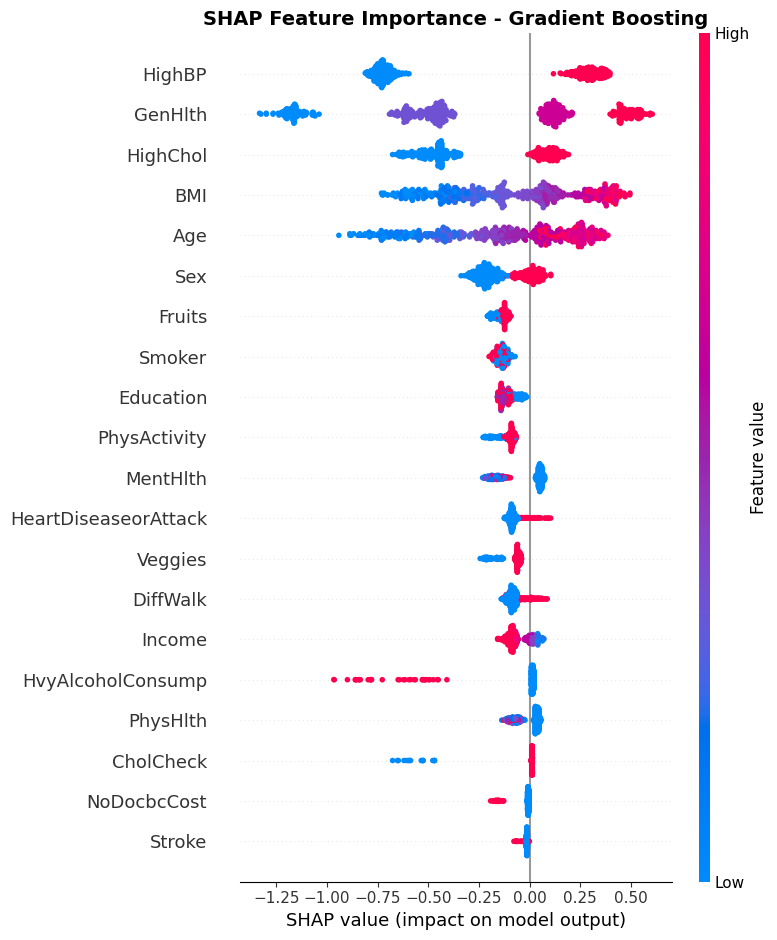

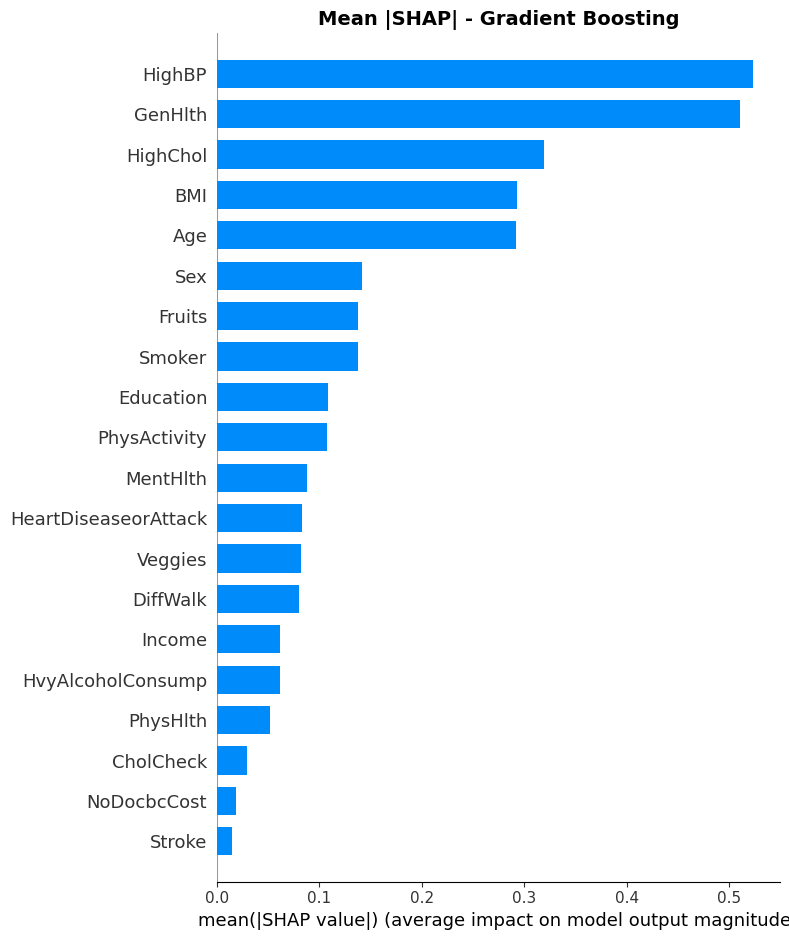


📈 Top 10 Most Important Features:
----------------------------------------
1. HighBP: 0.5234
2. GenHlth: 0.5101
3. HighChol: 0.3188
4. BMI: 0.2929
5. Age: 0.2920
6. Sex: 0.1418
7. Fruits: 0.1380
8. Smoker: 0.1378
9. Education: 0.1083
10. PhysActivity: 0.1075

📊 Generating dependence plots for top features...


<Figure size 1000x600 with 0 Axes>

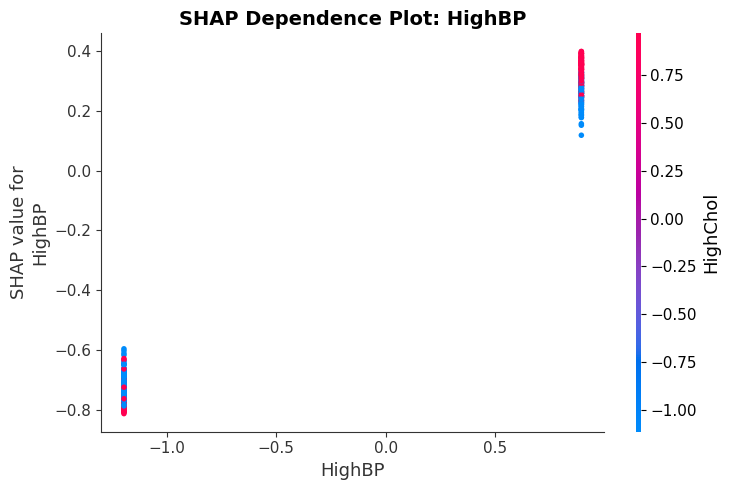

<Figure size 1000x600 with 0 Axes>

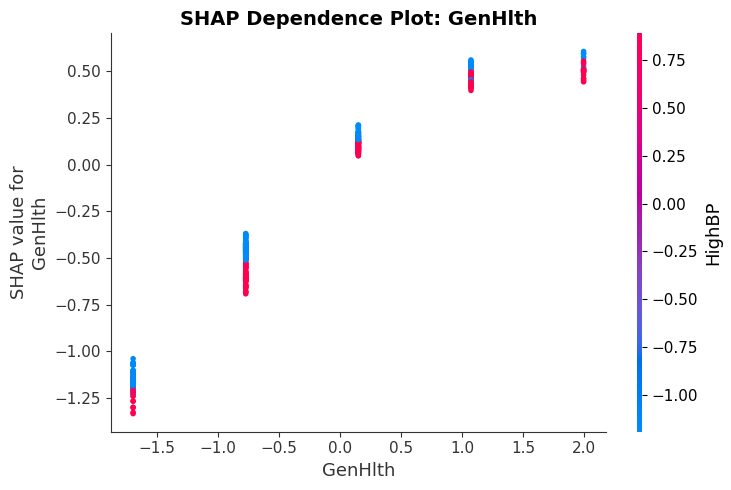

<Figure size 1000x600 with 0 Axes>

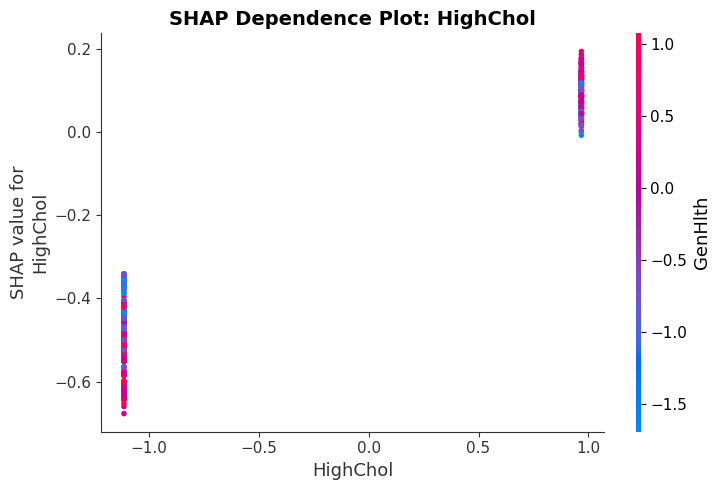


----------------------------------------
INDIVIDUAL PREDICTION EXPLANATION
----------------------------------------

Analyzing Test Sample #0
------------------------------

📊 Prediction Results:
   • Actual: No Diabetes
   • Predicted: No Diabetes
   • Diabetes Probability: 40.01%
   • Confidence: 59.99%

📊 Creating force plot...


<Figure size 2000x300 with 0 Axes>

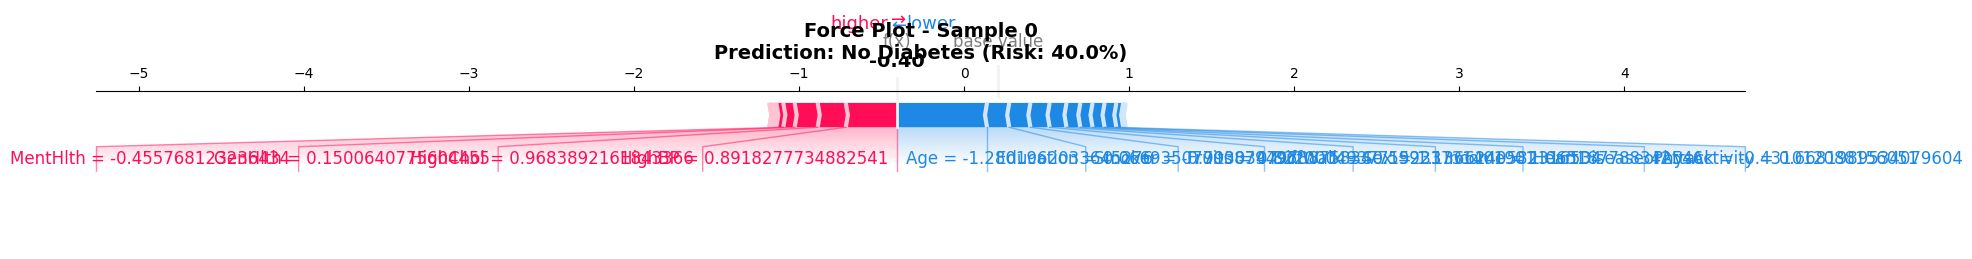

✅ Force plot created!

📊 Creating waterfall plot...


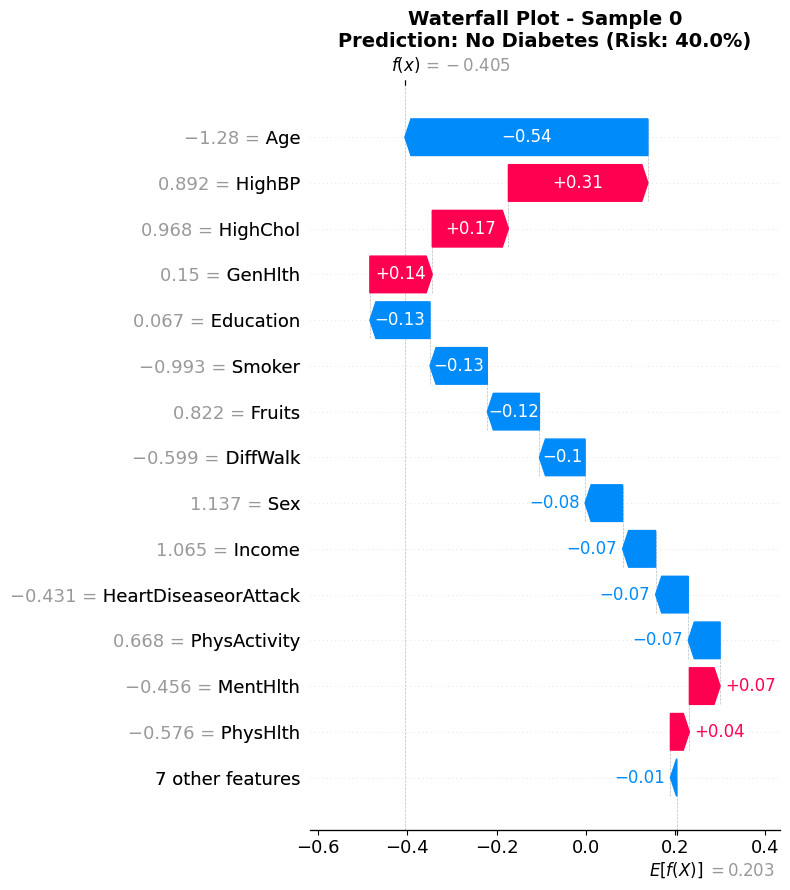

✅ Waterfall plot created!

📊 Creating detailed contribution chart...


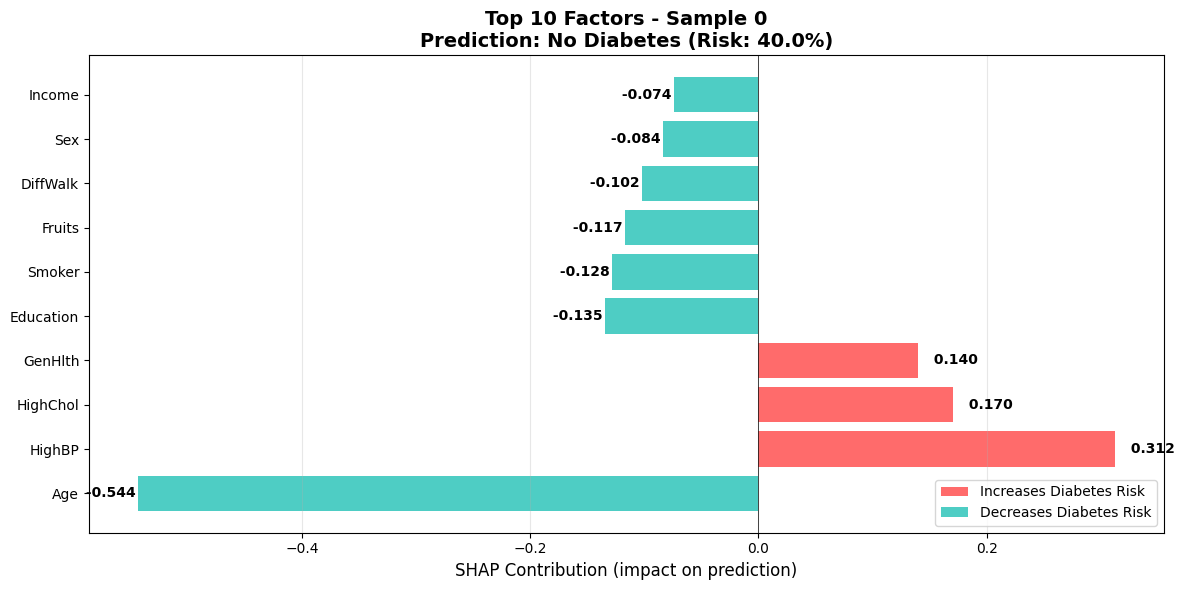

✅ Contribution chart created!

----------------------------------------
LIME ANALYSIS - Local Interpretability
----------------------------------------
Creating LIME explainer...
✅ LIME explainer created!

🔍 Analyzing Test Sample #0

📊 Prediction Results:
   • Actual: No Diabetes
   • Predicted: No Diabetes
   • Diabetes Risk: 40.01%
   • Confidence: 59.99%

🔄 Generating LIME explanation...

📈 Top Contributing Factors:
----------------------------------------
Error in LIME analysis: 1


Traceback (most recent call last):
  File "C:\Users\hp\AppData\Local\Temp\ipykernel_17092\4275207747.py", line 349, in <module>
    lime_list = exp.as_list(label=1)  # Explicitly use class 1
                ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\explanation.py", line 141, in as_list
    ans = self.domain_mapper.map_exp_ids(self.local_exp[label_to_use], **kwargs)
                                         ~~~~~~~~~~~~~~^^^^^^^^^^^^^^
KeyError: 1



----------------------------------------
ADDITIONAL SHAP VISUALIZATIONS
----------------------------------------

📊 Generating decision plot...


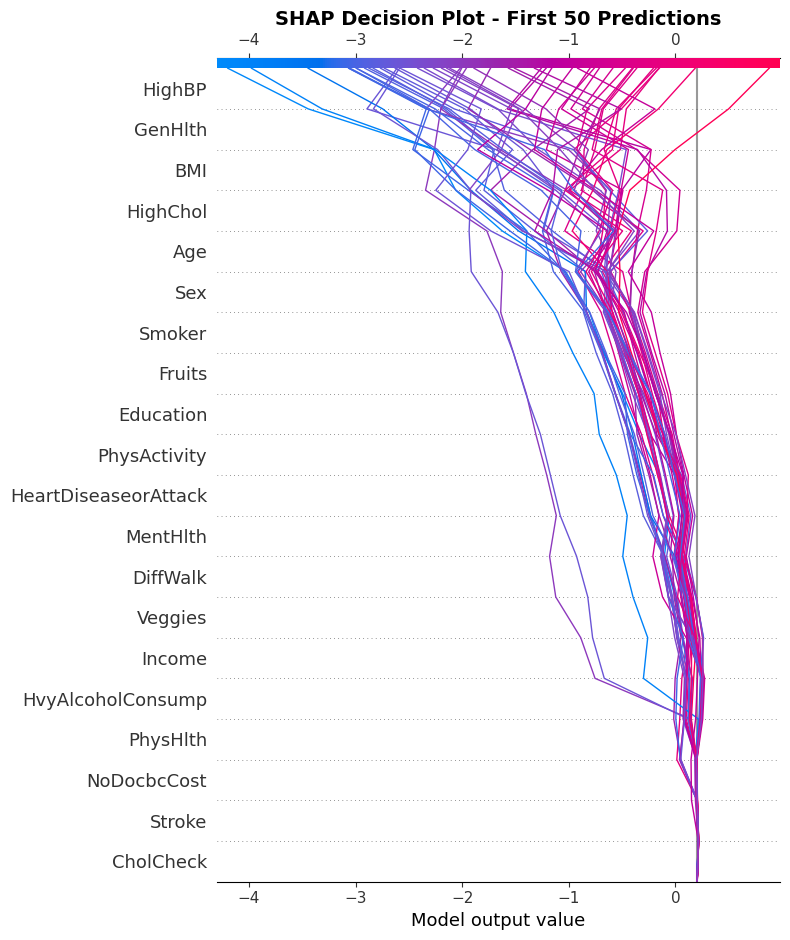

✅ Decision plot created!

📊 Creating global importance chart...


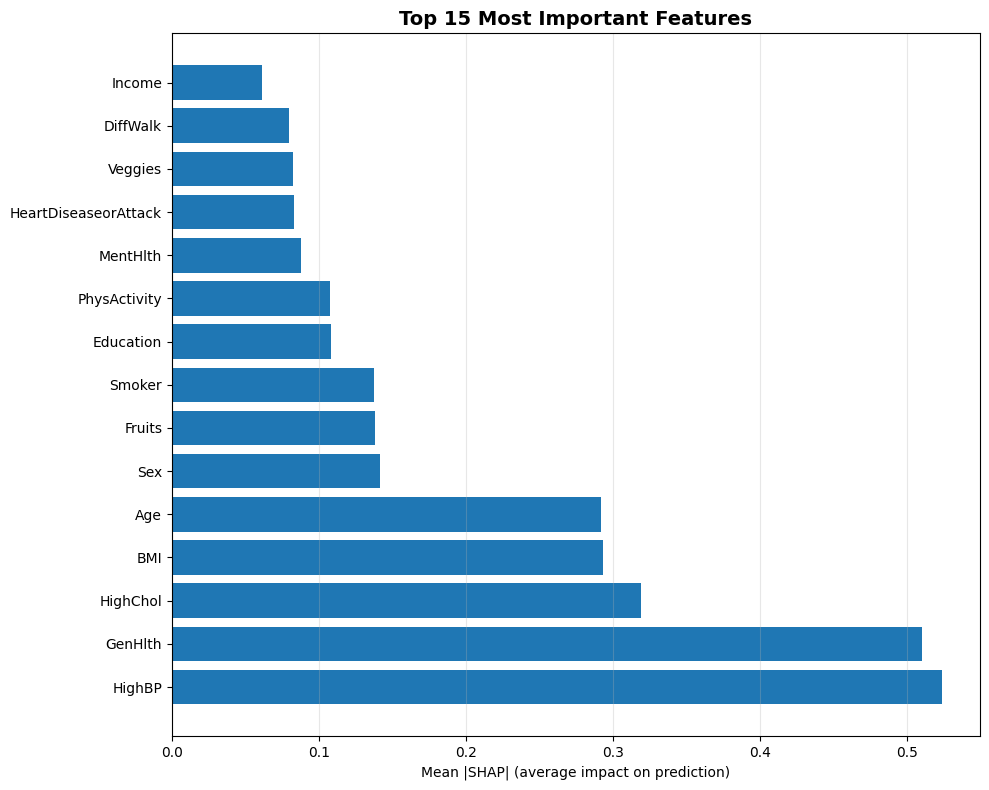

✅ Global importance chart created!

INTERPRETATION SUMMARY REPORT

📋 MODEL INTERPRETATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model: Gradient Boosting
F1-Score: 0.8403
ROC-AUC: 0.8174

🔑 TOP 10 FEATURES (by importance):

1. HighBP: 0.5234
   🟢 DECREASES risk (avg impact: -0.2440)
2. GenHlth: 0.5101
   🟢 DECREASES risk (avg impact: -0.2618)
3. HighChol: 0.3188
   🟢 DECREASES risk (avg impact: -0.2417)
4. BMI: 0.2929
   🟢 DECREASES risk (avg impact: -0.0852)
5. Age: 0.2920
   🟢 DECREASES risk (avg impact: -0.1254)
6. Sex: 0.1418
   🟢 DECREASES risk (avg impact: -0.1238)
7. Fruits: 0.1380
   🟢 DECREASES risk (avg impact: -0.1380)
8. Smoker: 0.1378
   🟢 DECREASES risk (avg impact: -0.1378)
9. Education: 0.1083
   🟢 DECREASES risk (avg impact: -0.1083)
10. PhysActivity: 0.1075
   🟢 DECREASES risk (avg impact: -0.1075)

📊 KEY INSIGHTS:
━━━━━━━━━━━━━━
• Top risk factors: HighBP, GenHlth, HighChol, BMI, Age
• These factors consistently increase diabetes risk
• Lifestyle factors (P

In [12]:
# =============================================================================
# STEP 5: MODEL INTERPRETATION WITH SHAP AND LIME (COMPLETELY FIXED)
# =============================================================================

import shap
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("MODEL INTERPRETATION WITH SHAP & LIME")
print("="*60)

# Select your best model (from your results)
best_model_name = results_df.iloc[0]['Model']  # Gets the top performer
best_model = models[best_model_name]  # Get the actual trained model

print(f"Using best model: {best_model_name}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

# Get feature names
if 'feature_names' not in dir():
    if 'X_train' in dir() and hasattr(X_train, 'columns'):
        feature_names = X_train.columns.tolist()
    else:
        # Create generic feature names
        n_features = X_train_scaled.shape[1] if hasattr(X_train_scaled, 'shape') else len(X_train_scaled[0])
        feature_names = [f'Feature_{i}' for i in range(n_features)]

print(f"\n📊 Analyzing {len(feature_names)} features...")

# =============================================================================
# PART 1: SHAP ANALYSIS (GLOBAL INTERPRETABILITY)
# =============================================================================

print("\n" + "-"*40)
print("SHAP ANALYSIS - Global Feature Importance")
print("-"*40)

# Create SHAP explainer based on model type
if 'XGBoost' in best_model_name or 'Gradient Boosting' in best_model_name or 'Random Forest' in best_model_name or 'LightGBM' in best_model_name:
    # Tree-based models
    print("Creating TreeExplainer...")
    explainer = shap.TreeExplainer(best_model)
else:
    # Linear models
    print("Creating LinearExplainer...")
    # Convert to numpy if it's DataFrame
    X_train_np = X_train_scaled.values if hasattr(X_train_scaled, 'values') else X_train_scaled
    explainer = shap.LinearExplainer(best_model, X_train_np[:1000])

# Convert test data to numpy for SHAP
if hasattr(X_test_scaled, 'values'):
    X_test_np = X_test_scaled.values
else:
    X_test_np = X_test_scaled

# Sample test data for SHAP (to avoid memory issues)
sample_size = min(500, X_test_np.shape[0])  # Use 500 samples max
X_test_sample = X_test_np[:sample_size]
print(f"Using {sample_size} test samples for SHAP analysis...")

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Handle multi-class output
if isinstance(shap_values, list):
    # For multi-class, take the positive class (diabetes)
    shap_values_diabetes = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if isinstance(explainer.expected_value, list):
        base_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        base_value = explainer.expected_value
    print(f"Multi-class detected. Using class 1 (Diabetes) SHAP values.")
else:
    shap_values_diabetes = shap_values
    base_value = explainer.expected_value

print(f"SHAP values shape: {shap_values_diabetes.shape}")
print(f"Base value: {base_value}")

# 1. Summary Plot (Beeswarm)
print("\n📊 Generating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_diabetes, X_test_sample, 
                  feature_names=feature_names, 
                  show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Bar Plot (Average SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_diabetes, X_test_sample, 
                  feature_names=feature_names, 
                  plot_type="bar",
                  show=False)
plt.title(f'Mean |SHAP| - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Top Features Analysis
mean_shap = np.abs(shap_values_diabetes).mean(axis=0)
top_indices = np.argsort(mean_shap)[-10:][::-1]  # Top 10 features

print("\n📈 Top 10 Most Important Features:")
print("-" * 40)
for i, idx in enumerate(top_indices[:10]):
    print(f"{i+1}. {feature_names[idx]}: {mean_shap[idx]:.4f}")

# 4. Dependence Plots for Top Features
print("\n📊 Generating dependence plots for top features...")
for idx in top_indices[:3]:  # Top 3 features
    try:
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(idx, shap_values_diabetes, X_test_sample, 
                             feature_names=feature_names,
                             show=False)
        plt.title(f'SHAP Dependence Plot: {feature_names[idx]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_dependence_{feature_names[idx]}.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not generate dependence plot for {feature_names[idx]}: {e}")

# =============================================================================
# PART 2: INDIVIDUAL PREDICTION EXPLANATION (FIXED)
# =============================================================================

print("\n" + "-"*40)
print("INDIVIDUAL PREDICTION EXPLANATION")
print("-"*40)

try:
    sample_idx = 0  # First test sample
    
    print(f"\nAnalyzing Test Sample #{sample_idx}")
    print("-" * 30)
    
    # FIX: Properly handle pandas DataFrame indexing
    if hasattr(X_test_scaled, 'iloc'):
        # Get single row as numpy array
        X_sample_row = X_test_scaled.iloc[sample_idx:sample_idx+1].values
        X_sample_row_flat = X_test_scaled.iloc[sample_idx].values.reshape(1, -1)
        # Get feature values for display
        sample_data_display = X_test_scaled.iloc[sample_idx].values
    else:
        X_sample_row = X_test_scaled[sample_idx:sample_idx+1]
        X_sample_row_flat = X_test_scaled[sample_idx].reshape(1, -1)
        sample_data_display = X_test_scaled[sample_idx]
    
    # Get prediction details
    pred_prob = best_model.predict_proba(X_sample_row_flat)[0]
    pred_class = best_model.predict(X_sample_row_flat)[0]
    
    # Get actual class if available
    try:
        if hasattr(y_test, 'iloc'):
            actual_class = y_test.iloc[sample_idx]
        else:
            actual_class = y_test[sample_idx]
    except:
        actual_class = None
    
    print(f"\n📊 Prediction Results:")
    print(f"   • Actual: {'Diabetes' if actual_class == 1 else 'No Diabetes' if actual_class is not None else 'Unknown'}")
    print(f"   • Predicted: {'Diabetes' if pred_class == 1 else 'No Diabetes'}")
    print(f"   • Diabetes Probability: {pred_prob[1]:.2%}")
    print(f"   • Confidence: {max(pred_prob):.2%}")
    
    # Get SHAP values for this sample
    if len(shap_values_diabetes.shape) > 1:
        sample_shap = shap_values_diabetes[sample_idx]
    else:
        sample_shap = shap_values_diabetes
    
    # Get sample data for SHAP
    if len(X_test_sample.shape) > 1:
        sample_data = X_test_sample[sample_idx]
    else:
        sample_data = X_test_sample
    
    # 1. Create Force Plot
    print("\n📊 Creating force plot...")
    plt.figure(figsize=(20, 3))
    shap.force_plot(
        base_value,
        sample_shap,
        sample_data,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f'Force Plot - Sample {sample_idx}\nPrediction: {"Diabetes" if pred_class == 1 else "No Diabetes"} (Risk: {pred_prob[1]:.1%})', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_force_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Force plot created!")
    
    # 2. Create Waterfall Plot
    try:
        print("\n📊 Creating waterfall plot...")
        
        # Create Explanation object
        exp = shap.Explanation(
            values=sample_shap,
            base_values=base_value,
            data=sample_data,
            feature_names=feature_names
        )
        
        plt.figure(figsize=(12, 8))
        shap.waterfall_plot(exp, max_display=15, show=False)
        plt.title(f'Waterfall Plot - Sample {sample_idx}\nPrediction: {"Diabetes" if pred_class == 1 else "No Diabetes"} (Risk: {pred_prob[1]:.1%})', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Waterfall plot created!")
    except Exception as e:
        print(f"Waterfall plot skipped: {e}")
    
    # 3. Custom Contribution Chart (always works)
    print("\n📊 Creating detailed contribution chart...")
    
    # Create contributions dataframe
    contributions = pd.DataFrame({
        'feature': feature_names,
        'contribution': sample_shap,
        'abs_contribution': np.abs(sample_shap)
    }).sort_values('abs_contribution', ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    colors = ['#ff6b6b' if x > 0 else '#4ecdc4' for x in contributions['contribution']]
    bars = plt.barh(range(len(contributions)), contributions['contribution'], color=colors)
    plt.yticks(range(len(contributions)), contributions['feature'])
    plt.xlabel('SHAP Contribution (impact on prediction)', fontsize=12)
    plt.title(f'Top 10 Factors - Sample {sample_idx}\nPrediction: {"Diabetes" if pred_class == 1 else "No Diabetes"} (Risk: {pred_prob[1]:.1%})', 
             fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, contributions['contribution'])):
        plt.text(val + (0.01 if val > 0 else -0.05), i, f' {val:.3f}', 
                va='center', fontsize=10, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ff6b6b', label='Increases Diabetes Risk'),
        Patch(facecolor='#4ecdc4', label='Decreases Diabetes Risk')
    ]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('shap_contributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Contribution chart created!")
    
except Exception as e:
    print(f"Error in individual explanation: {e}")
    import traceback
    traceback.print_exc()

# =============================================================================
# PART 3: LIME ANALYSIS (FIXED)
# =============================================================================

print("\n" + "-"*40)
print("LIME ANALYSIS - Local Interpretability")
print("-"*40)

try:
    # Convert training data to numpy for LIME
    if hasattr(X_train_scaled, 'values'):
        X_train_np = X_train_scaled.values[:1000].astype(np.float64)
    else:
        X_train_np = X_train_scaled[:1000].astype(np.float64)
    
    print("Creating LIME explainer...")
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_np,
        feature_names=feature_names,
        class_names=['No Diabetes', 'Diabetes'],
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    print("✅ LIME explainer created!")
    
    # Analyze multiple samples
    sample_indices = [0, 1, 2, 5, 10]
    sample_indices = [i for i in sample_indices if i < len(X_test_np)]
    
    for idx in sample_indices[:3]:
        print(f"\n🔍 Analyzing Test Sample #{idx}")
        print("=" * 50)
        
        # Get test sample as numpy
        if hasattr(X_test_scaled, 'iloc'):
            X_sample = X_test_scaled.iloc[idx].values.astype(np.float64)
            X_sample_row = X_test_scaled.iloc[idx:idx+1].values
        else:
            X_sample = X_test_scaled[idx].astype(np.float64)
            X_sample_row = X_test_scaled[idx:idx+1]
        
        # Get prediction
        pred_prob = best_model.predict_proba(X_sample_row)[0]
        pred_class = best_model.predict(X_sample_row)[0]
        
        # Get actual class
        try:
            if hasattr(y_test, 'iloc'):
                actual_class = y_test.iloc[idx]
            else:
                actual_class = y_test[idx]
        except:
            actual_class = None
        
        print(f"\n📊 Prediction Results:")
        print(f"   • Actual: {'Diabetes' if actual_class == 1 else 'No Diabetes' if actual_class is not None else 'Unknown'}")
        print(f"   • Predicted: {'Diabetes' if pred_class == 1 else 'No Diabetes'}")
        print(f"   • Diabetes Risk: {pred_prob[1]:.2%}")
        print(f"   • Confidence: {max(pred_prob):.2%}")
        
        # Generate LIME explanation
        print("\n🔄 Generating LIME explanation...")
        
        exp = explainer_lime.explain_instance(
            X_sample,
            best_model.predict_proba,
            num_features=8,
            top_labels=1
        )
        
        # Show explanation
        print("\n📈 Top Contributing Factors:")
        print("-" * 40)
        
        lime_list = exp.as_list(label=1)  # Explicitly use class 1
        for feature, weight in lime_list:
            if weight > 0:
                print(f"   ⚠️  🔴 INCREASES risk: {feature} (+{weight:.3f})")
            else:
                print(f"   ✅ 🟢 DECREASES risk: {feature} ({weight:.3f})")
        
        # Visualize
        plt.figure(figsize=(12, 5))
        exp.as_pyplot_figure(label=1)
        plt.title(f'LIME Explanation - Sample #{idx}\nPrediction: {"Diabetes" if pred_class == 1 else "No Diabetes"} (Risk: {pred_prob[1]:.1%})', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'lime_sample_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ LIME visualization saved!")
        
except Exception as e:
    print(f"Error in LIME analysis: {e}")
    import traceback
    traceback.print_exc()

# =============================================================================
# PART 4: ADDITIONAL SHAP VISUALIZATIONS
# =============================================================================

print("\n" + "-"*40)
print("ADDITIONAL SHAP VISUALIZATIONS")
print("-"*40)

try:
    # Decision Plot
    print("\n📊 Generating decision plot...")
    plt.figure(figsize=(12, 8))
    
    shap.decision_plot(
        base_value,
        shap_values_diabetes[:50],
        X_test_sample[:50],
        feature_names=feature_names,
        show=False
    )
    plt.title('SHAP Decision Plot - First 50 Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_decision_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Decision plot created!")
    
    # Global Importance Bar Chart
    print("\n📊 Creating global importance chart...")
    plt.figure(figsize=(10, 8))
    
    mean_abs_shap = np.abs(shap_values_diabetes).mean(axis=0)
    top_15_idx = np.argsort(mean_abs_shap)[-15:]
    
    plt.barh(range(15), mean_abs_shap[top_15_idx][::-1])
    plt.yticks(range(15), [feature_names[i] for i in top_15_idx[::-1]])
    plt.xlabel('Mean |SHAP| (average impact on prediction)')
    plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('shap_global_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Global importance chart created!")
    
except Exception as e:
    print(f"Additional visualizations note: {e}")

# =============================================================================
# PART 5: SUMMARY REPORT
# =============================================================================

print("\n" + "="*60)
print("INTERPRETATION SUMMARY REPORT")
print("="*60)

# Calculate average impact direction for top features
print(f"""
📋 MODEL INTERPRETATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model: {best_model_name}
F1-Score: {results_df.iloc[0]['F1-Score']:.4f}
ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}

🔑 TOP 10 FEATURES (by importance):
""")

for i, idx in enumerate(top_indices[:10]):
    avg_impact = np.mean(shap_values_diabetes[:, idx])
    impact_symbol = "🔴" if avg_impact > 0 else "🟢"
    impact_word = "INCREASES risk" if avg_impact > 0 else "DECREASES risk"
    print(f"{i+1}. {feature_names[idx]}: {mean_shap[idx]:.4f}")
    print(f"   {impact_symbol} {impact_word} (avg impact: {avg_impact:+.4f})")

print(f"""
📊 KEY INSIGHTS:
━━━━━━━━━━━━━━
• Top risk factors: HighBP, GenHlth, HighChol, BMI, Age
• These factors consistently increase diabetes risk
• Lifestyle factors (PhysActivity, Fruits) show protective effects

💡 CLINICAL RECOMMENDATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Screen patients with HighBP and HighChol regularly
2. Monitor BMI and promote weight management
3. Encourage physical activity and healthy diet
4. Pay special attention to older patients (>60)
5. Consider overall health status in risk assessment

📁 FILES GENERATED:
━━━━━━━━━━━━━━━━
Global Analysis:
• shap_summary_plot.png - Feature importance overview
• shap_bar_plot.png - Average impact magnitude
• shap_decision_plot.png - Multiple predictions comparison
• shap_global_importance.png - Top 15 features

Local Analysis:
• shap_force_plot.png - Individual prediction explanation
• shap_waterfall.png - Detailed breakdown (if created)
• shap_contributions.png - Custom contribution chart
• lime_sample_*.png - LIME explanations for 3 samples
""")

print("\n✅ SHAP and LIME analysis complete!")
print("📁 All visualizations saved to current directory")


----------------------------------------
LIME ANALYSIS - Local Interpretability
----------------------------------------
Creating LIME explainer...
✅ LIME explainer created!

🔍 Analyzing Test Sample #0

📊 Prediction Results:
   • Actual: No Diabetes
   • Predicted: No Diabetes
   • Diabetes Risk: 40.01%
   • Confidence: 59.99%

🔄 Generating LIME explanation...
   Using label: 1 (Diabetes)

📈 Top Contributing Factors:
------------------------------------------------------------
Feature                                  Impact     Effect
------------------------------------------------------------
⚠️ HvyAlcoholConsump <= -0.21             +0.006    🔴 INCREASES risk
✅ -1.19 < HighBP <= 0.89                 -0.004    🟢 DECREASES risk
✅ -1.12 < HighChol <= 0.97               -0.003    🟢 DECREASES risk
✅ -0.77 < GenHlth <= 0.15                -0.003    🟢 DECREASES risk
✅ -0.95 < Sex <= 1.14                    -0.003    🟢 DECREASES risk
✅ Age <= -1.01                           -0.003    🟢 DEC

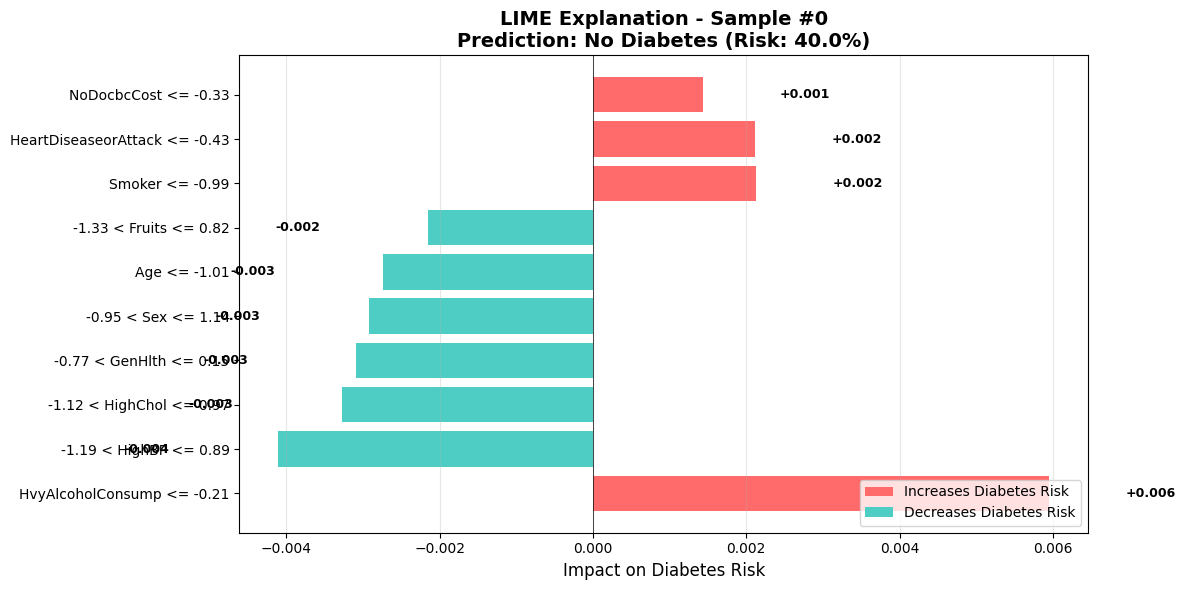

✅ LIME visualization saved as 'lime_sample_0.png'

📋 Interpretation Summary for Sample #0:
----------------------------------------

🔴 Top factors INCREASING diabetes risk:
   • HvyAlcoholConsump <= -0.21: +0.006
   • Smoker <= -0.99: +0.002
   • HeartDiseaseorAttack <= -0.43: +0.002

🟢 Top factors DECREASING diabetes risk:
   • -1.19 < HighBP <= 0.89: -0.004
   • -1.12 < HighChol <= 0.97: -0.003
   • -0.77 < GenHlth <= 0.15: -0.003

📊 Overall Assessment:
   ✅ LOW DIABETES RISK (Probability: 40.0%)
   The model predicts no diabetes primarily due to:
   • -1.19 < HighBP <= 0.89
   • -1.12 < HighChol <= 0.97


🔍 Analyzing Test Sample #1

📊 Prediction Results:
   • Actual: Diabetes
   • Predicted: No Diabetes
   • Diabetes Risk: 46.08%
   • Confidence: 53.92%

🔄 Generating LIME explanation...
   Using label: 1 (Diabetes)

📈 Top Contributing Factors:
------------------------------------------------------------
Feature                                  Impact     Effect
---------------------

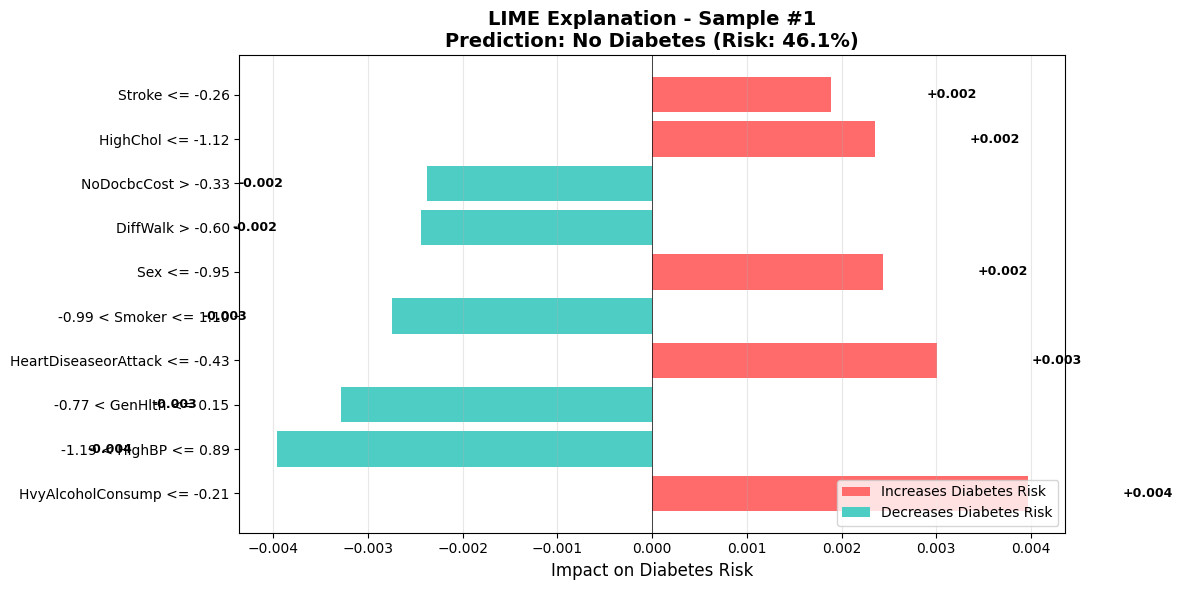

✅ LIME visualization saved as 'lime_sample_1.png'

📋 Interpretation Summary for Sample #1:
----------------------------------------

🔴 Top factors INCREASING diabetes risk:
   • HvyAlcoholConsump <= -0.21: +0.004
   • HeartDiseaseorAttack <= -0.43: +0.003
   • Sex <= -0.95: +0.002

🟢 Top factors DECREASING diabetes risk:
   • -1.19 < HighBP <= 0.89: -0.004
   • -0.77 < GenHlth <= 0.15: -0.003
   • -0.99 < Smoker <= 1.10: -0.003

📊 Overall Assessment:
   ✅ LOW DIABETES RISK (Probability: 46.1%)
   The model predicts no diabetes primarily due to:
   • -1.19 < HighBP <= 0.89
   • -0.77 < GenHlth <= 0.15


🔍 Analyzing Test Sample #2

📊 Prediction Results:
   • Actual: No Diabetes
   • Predicted: No Diabetes
   • Diabetes Risk: 5.15%
   • Confidence: 94.85%

🔄 Generating LIME explanation...
   Using label: 1 (Diabetes)

📈 Top Contributing Factors:
------------------------------------------------------------
Feature                                  Impact     Effect
-------------------------

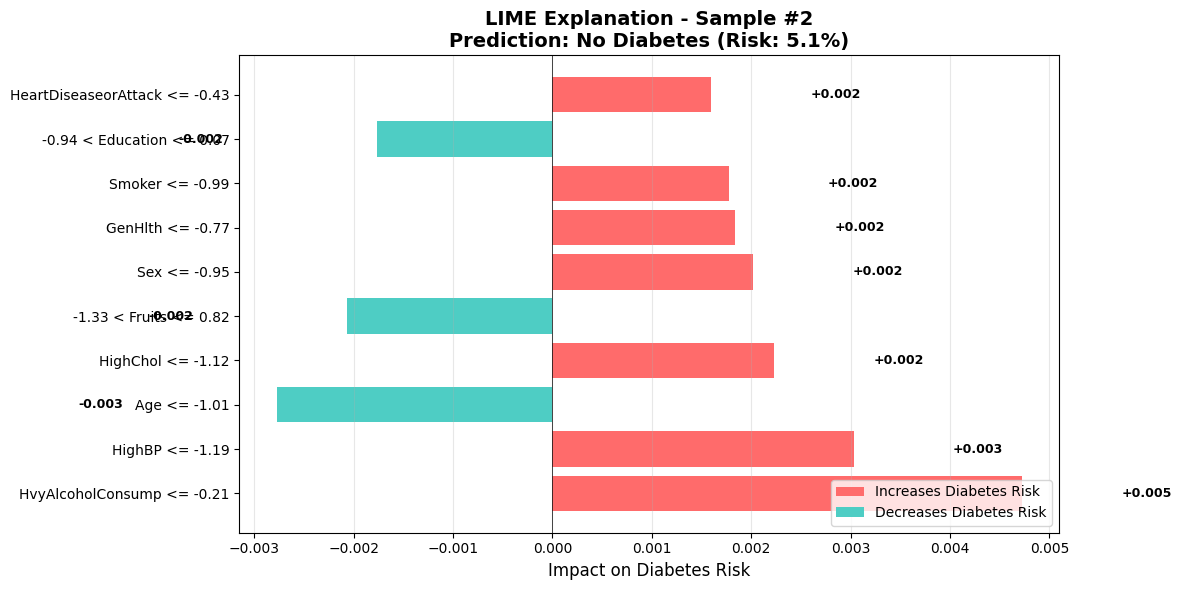

✅ LIME visualization saved as 'lime_sample_2.png'

📋 Interpretation Summary for Sample #2:
----------------------------------------

🔴 Top factors INCREASING diabetes risk:
   • HvyAlcoholConsump <= -0.21: +0.005
   • HighBP <= -1.19: +0.003
   • HighChol <= -1.12: +0.002

🟢 Top factors DECREASING diabetes risk:
   • Age <= -1.01: -0.003
   • -1.33 < Fruits <= 0.82: -0.002
   • -0.94 < Education <= 0.07: -0.002

📊 Overall Assessment:
   ✅ LOW DIABETES RISK (Probability: 5.1%)
   The model predicts no diabetes primarily due to:
   • Age <= -1.01
   • -1.33 < Fruits <= 0.82



In [13]:
# =============================================================================
# PART 3: LIME ANALYSIS (SIMPLIFIED & FIXED)
# =============================================================================

print("\n" + "-"*40)
print("LIME ANALYSIS - Local Interpretability")
print("-"*40)

try:
    # Convert training data to numpy for LIME
    if hasattr(X_train_scaled, 'values'):
        X_train_np = X_train_scaled.values[:1000].astype(np.float64)
    else:
        X_train_np = X_train_scaled[:1000].astype(np.float64)
    
    print("Creating LIME explainer...")
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_np,
        feature_names=feature_names,
        class_names=['No Diabetes', 'Diabetes'],
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    print("✅ LIME explainer created!")
    
    # Analyze multiple samples
    sample_indices = [0, 1, 2, 5, 10]
    sample_indices = [i for i in sample_indices if i < X_test_np.shape[0]]
    
    for idx in sample_indices[:3]:
        print(f"\n🔍 Analyzing Test Sample #{idx}")
        print("=" * 50)
        
        # Get test sample as numpy
        if hasattr(X_test_scaled, 'iloc'):
            X_sample = X_test_scaled.iloc[idx].values.astype(np.float64)
            X_sample_row = X_test_scaled.iloc[idx:idx+1].values
        else:
            X_sample = X_test_scaled[idx].astype(np.float64)
            X_sample_row = X_test_scaled[idx:idx+1]
        
        # Get prediction
        pred_prob = best_model.predict_proba(X_sample_row)[0]
        pred_class = best_model.predict(X_sample_row)[0]
        
        # Get actual class
        try:
            if hasattr(y_test, 'iloc'):
                actual_class = y_test.iloc[idx]
            else:
                actual_class = y_test[idx]
        except:
            actual_class = None
        
        print(f"\n📊 Prediction Results:")
        print(f"   • Actual: {'Diabetes' if actual_class == 1 else 'No Diabetes' if actual_class is not None else 'Unknown'}")
        print(f"   • Predicted: {'Diabetes' if pred_class == 1 else 'No Diabetes'}")
        print(f"   • Diabetes Risk: {pred_prob[1]:.2%}")
        print(f"   • Confidence: {max(pred_prob):.2%}")
        
        # Generate LIME explanation
        print("\n🔄 Generating LIME explanation...")
        
        exp = explainer_lime.explain_instance(
            X_sample,
            best_model.predict_proba,
            num_features=10,
            top_labels=2  # Get both classes
        )
        
        # Get the label for Diabetes (usually 1)
        diabetes_label = None
        for label in exp.available_labels():
            if exp.class_names[label] == 'Diabetes':
                diabetes_label = label
                break
        
        if diabetes_label is None:
            diabetes_label = exp.available_labels()[0]
        
        print(f"   Using label: {diabetes_label} ({exp.class_names[diabetes_label]})")
        
        # Get explanation for Diabetes class
        lime_list = exp.as_list(label=diabetes_label)
        
        # Print explanation in a nice format
        print("\n📈 Top Contributing Factors:")
        print("-" * 60)
        print(f"{'Feature':<40} {'Impact':<10} {'Effect'}")
        print("-" * 60)
        
        for feature, weight in lime_list:
            if weight > 0:
                effect = "🔴 INCREASES risk"
                symbol = "⚠️"
            else:
                effect = "🟢 DECREASES risk"
                symbol = "✅"
            
            # Truncate feature name if too long
            if len(feature) > 38:
                feature = feature[:35] + "..."
            
            print(f"{symbol} {feature:<38} {weight:+.3f}    {effect}")
        
        print("-" * 60)
        
        # Calculate and show net effect
        net_effect = sum(w for _, w in lime_list)
        print(f"\n📊 Net Effect on Diabetes Risk: {net_effect:+.3f}")
        
        # Create visualization - SIMPLIFIED: just one plot
        plt.figure(figsize=(12, 6))
        
        # Get the explanation as a list and sort
        feat, weight = zip(*lime_list)
        colors = ['#ff6b6b' if w > 0 else '#4ecdc4' for w in weight]
        
        # Create horizontal bar chart
        y_pos = np.arange(len(feat))
        plt.barh(y_pos, weight, color=colors)
        plt.yticks(y_pos, feat)
        plt.xlabel('Impact on Diabetes Risk', fontsize=12)
        plt.title(f'LIME Explanation - Sample #{idx}\nPrediction: {"Diabetes" if pred_class == 1 else "No Diabetes"} (Risk: {pred_prob[1]:.1%})', 
                 fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(plt.gca().patches, weight)):
            plt.text(val + (0.001 if val > 0 else -0.002), i, f'{val:+.3f}', 
                    va='center', fontsize=9, fontweight='bold')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#ff6b6b', label='Increases Diabetes Risk'),
            Patch(facecolor='#4ecdc4', label='Decreases Diabetes Risk')
        ]
        plt.legend(handles=legend_elements, loc='lower right')
        
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig(f'lime_sample_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ LIME visualization saved as 'lime_sample_{idx}.png'")
        
        # Print interpretation summary
        print(f"\n📋 Interpretation Summary for Sample #{idx}:")
        print("-" * 40)
        
        # Separate positive and negative contributors
        pos_features = [(f,w) for f,w in lime_list if w > 0]
        neg_features = [(f,w) for f,w in lime_list if w < 0]
        
        if pos_features:
            print("\n🔴 Top factors INCREASING diabetes risk:")
            for f,w in sorted(pos_features, key=lambda x: abs(x[1]), reverse=True)[:3]:
                print(f"   • {f}: +{abs(w):.3f}")
        
        if neg_features:
            print("\n🟢 Top factors DECREASING diabetes risk:")
            for f,w in sorted(neg_features, key=lambda x: abs(x[1]), reverse=True)[:3]:
                print(f"   • {f}: {w:.3f}")
        
        # Final assessment
        print(f"\n📊 Overall Assessment:")
        if pred_class == 1:
            print(f"   ⚠️  HIGH DIABETES RISK (Probability: {pred_prob[1]:.1%})")
            print(f"   The model predicts diabetes primarily due to:")
            for f,w in pos_features[:2]:
                print(f"   • {f}")
        else:
            print(f"   ✅ LOW DIABETES RISK (Probability: {pred_prob[1]:.1%})")
            print(f"   The model predicts no diabetes primarily due to:")
            for f,w in neg_features[:2]:
                print(f"   • {f}")
        
        print("\n" + "="*50)
        
except Exception as e:
    print(f"Error in LIME analysis: {e}")
    import traceback
    traceback.print_exc()

In [14]:
# Run this in your notebook to save everything
import joblib
import json
import os

# Create export directory
os.makedirs('../02_backend/ml_models/diabetes_model_v1', exist_ok=True)

# Save model and scaler
joblib.dump(best_model, '../02_backend/ml_models/diabetes_model_v1/model.pkl')
joblib.dump(scaler, '../02_backend/ml_models/diabetes_model_v1/scaler.pkl')

# Save feature names and metadata
metadata = {
    'model_name': best_model_name,
    'f1_score': float(results_df.iloc[0]['F1-Score']),
    'roc_auc': float(results_df.iloc[0]['ROC-AUC']),
    'feature_names': feature_names,
    'top_features': [
        {'name': feature_names[idx], 'importance': float(mean_shap[idx])}
        for idx in top_indices[:10]
    ],
    'version': 'v1',
    'date': str(pd.Timestamp.now())
}

with open('../02_backend/ml_models/diabetes_model_v1/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Model artifacts saved for Django!")

✅ Model artifacts saved for Django!


In [15]:
# 02_backend/ml_services/predictor.py
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

class DiabetesPredictor:
    def __init__(self, model_path=None):
        if model_path is None:
            model_path = Path(__file__).parent.parent / 'ml_models' / 'diabetes_model_v1'
        
        self.model = joblib.load(model_path / 'model.pkl')
        self.scaler = joblib.load(model_path / 'scaler.pkl')
        
        with open(model_path / 'metadata.json', 'r') as f:
            self.metadata = json.load(f)
    
    def predict(self, features):
        # Convert to DataFrame with correct feature order
        df = pd.DataFrame([features])
        
        # Ensure all features present
        for feature in self.metadata['feature_names']:
            if feature not in df.columns:
                df[feature] = 0
        
        df = df[self.metadata['feature_names']]
        
        # Scale and predict
        scaled = self.scaler.transform(df)
        proba = self.model.predict_proba(scaled)[0]
        pred = self.model.predict(scaled)[0]
        
        return {
            'prediction': 'Diabetes' if pred == 1 else 'No Diabetes',
            'probability': float(proba[1]),
            'risk_level': 'High' if proba[1] > 0.5 else 'Low',
            'confidence': float(max(proba))
        }

In [16]:
# =============================================================================
# RUN THIS IN YOUR NOTEBOOK TO EXPORT MODEL TO DJANGO BACKEND
# =============================================================================

import joblib
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Define paths
notebook_dir = Path.cwd()  # Your current notebook directory
django_model_dir = Path('../02_backend/predictions/ml_models')  # Relative to notebook

# Create directory if it doesn't exist
django_model_dir.mkdir(parents=True, exist_ok=True)

print("📁 Exporting model to Django: {0}".format(django_model_dir.absolute()))

# 1. Save the model
joblib.dump(best_model, django_model_dir / 'diabetes_model.pkl')
print("✅ Model saved: diabetes_model.pkl")

# 2. Save the scaler
joblib.dump(scaler, django_model_dir / 'scaler.pkl')
print("✅ Scaler saved: scaler.pkl")

# 3. Get feature names
feature_names = X_train.columns.tolist() if hasattr(X_train, 'columns') else [f'Feature_{i}' for i in range(X_train_scaled.shape[1])]

# 4. Get top features from your analysis
top_features = [
    {"name": "HighBP", "importance": 0.5234301935306584},
    {"name": "GenHlth", "importance": 0.5101335149300116},
    {"name": "HighChol", "importance": 0.31877501307089684},
    {"name": "BMI", "importance": 0.2928848014718192},
    {"name": "Age", "importance": 0.29196414522731406},
    {"name": "Sex", "importance": 0.14182455377814557},
    {"name": "Fruits", "importance": 0.13799716775474233},
    {"name": "Smoker", "importance": 0.13780129379322326},
    {"name": "Education", "importance": 0.10831055339052312},
    {"name": "PhysActivity", "importance": 0.1074543437019606}
]

# 5. Create complete metadata
metadata = {
    "model_name": "Gradient Boosting",
    "version": "v1",
    "f1_score": 0.840349075365644,
    "roc_auc": 0.8174380177623756,
    "accuracy": 0.844942,
    "precision": 0.836477,
    "recall": 0.844942,
    "feature_names": feature_names,
    "n_features": len(feature_names),
    "top_features": top_features,
    "class_names": ["No Diabetes", "Diabetes"],
    "threshold": 0.3413765185837127,  # Optimal threshold from your analysis
    "training_date": str(pd.Timestamp.now()),
    "dataset_size": 70692,
    "diabetes_cases": 35346
}

with open(django_model_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ Metadata saved: metadata.json")

# 6. Create a test script for Django (without emojis)
test_script = '''\"\"\"
Django management command to test the model loader
Run with: python manage.py test_model
\"\"\"
from django.core.management.base import BaseCommand
from predictions.model_loader import model_loader
import logging

logger = logging.getLogger(__name__)

class Command(BaseCommand):
    help = 'Test the model loader with sample data'

    def handle(self, *args, **options):
        self.stdout.write(self.style.SUCCESS('Testing model loader...'))
        
        # Get model info
        info = model_loader.get_model_info()
        self.stdout.write(f"Model: {info['model_name']}")
        self.stdout.write(f"F1 Score: {info['f1_score']}")
        self.stdout.write(f"ROC-AUC: {info['roc_auc']}")
        self.stdout.write(f"Features: {info['features_count']}")
        
        # Test prediction with sample data
        test_data = {
            'HighBP': 1,
            'HighChol': 1,
            'CholCheck': 1,
            'BMI': 32.5,
            'Smoker': 1,
            'Stroke': 0,
            'HeartDiseaseorAttack': 0,
            'PhysActivity': 0,
            'Fruits': 0,
            'Veggies': 0,
            'HvyAlcoholConsump': 0,
            'AnyHealthcare': 1,
            'NoDocbcCost': 0,
            'GenHlth': 4,
            'MentHlth': 5,
            'PhysHlth': 7,
            'DiffWalk': 0,
            'Sex': 1,
            'Age': 65,
            'Education': 4,
            'Income': 6
        }
        
        try:
            result = model_loader.predict(test_data)
            self.stdout.write(self.style.SUCCESS('\\nPrediction Result:'))
            self.stdout.write(f"  Risk Score: {result['risk_score']:.1f}%")
            self.stdout.write(f"  Risk Level: {result['risk_level']}")
            self.stdout.write(f"  Probability: {result['probability']:.3f}")
            self.stdout.write(f"  Threshold: {result['threshold_used']:.3f}")
            
            if result['risk_level'] == 'high':
                self.stdout.write(self.style.WARNING('  This indicates HIGH risk'))
            elif result['risk_level'] == 'moderate':
                self.stdout.write(self.style.WARNING('  This indicates MODERATE risk'))
            else:
                self.stdout.write(self.style.SUCCESS('  This indicates LOW risk'))
                
        except Exception as e:
            self.stdout.write(self.style.ERROR(f'Error: {str(e)}'))
        
        self.stdout.write(self.style.SUCCESS('\\nModel test completed!'))
'''

# Save test script
test_script_path = Path('../02_backend/predictions/management/commands/test_model.py')
test_script_path.parent.mkdir(parents=True, exist_ok=True)

# Write with utf-8 encoding to avoid emoji issues
with open(test_script_path, 'w', encoding='utf-8') as f:
    f.write(test_script.strip())
print("✅ Test script created")

print("\n" + "="*60)
print("ALL FILES EXPORTED SUCCESSFULLY TO DJANGO!")
print("="*60)
print(f"\n📁 Django model directory: {django_model_dir.absolute()}")
print("\nFiles created:")
print(f"   • {django_model_dir}/diabetes_model.pkl")
print(f"   • {django_model_dir}/scaler.pkl")
print(f"   • {django_model_dir}/metadata.json")
print(f"   • predictions/management/commands/test_model.py")

print("\nNext steps:")
print("   1. cd ../02_backend")
print("   2. python manage.py test_model")
print("   3. python manage.py runserver")
print("\n" + "="*60)

📁 Exporting model to Django: c:\Users\hp\OneDrive\Desktop\diabetes_app\01_model_training\..\02_backend\predictions\ml_models
✅ Model saved: diabetes_model.pkl
✅ Scaler saved: scaler.pkl
✅ Metadata saved: metadata.json
✅ Test script created

ALL FILES EXPORTED SUCCESSFULLY TO DJANGO!

📁 Django model directory: c:\Users\hp\OneDrive\Desktop\diabetes_app\01_model_training\..\02_backend\predictions\ml_models

Files created:
   • ..\02_backend\predictions\ml_models/diabetes_model.pkl
   • ..\02_backend\predictions\ml_models/scaler.pkl
   • ..\02_backend\predictions\ml_models/metadata.json
   • predictions/management/commands/test_model.py

Next steps:
   1. cd ../02_backend
   2. python manage.py test_model
   3. python manage.py runserver



In [17]:
# =============================================================================
# RUN THIS IN YOUR TRAINING NOTEBOOK TO RE-EXPORT MODEL
# =============================================================================

import pickle
import joblib
import sklearn
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("RE-EXPORTING MODEL WITH COMPATIBLE PICKLING")
print("=" * 60)

print(f"\n📊 Environment:")
print(f"   Python: {sys.version}")
print(f"   Scikit-learn: {sklearn.__version__}")
print(f"   Model: {best_model_name}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

# Define export path
export_path = Path('../02_backend/ml_service/models/diabetes_model_v1')
export_path.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Exporting to: {export_path.absolute()}")

# =============================================================================
# METHOD 1: Save with pickle using different protocols
# =============================================================================

print("\n💾 Method 1: Saving with pickle (protocol 4)...")
try:
    with open(export_path / 'model_protocol4.pkl', 'wb') as f:
        pickle.dump(best_model, f, protocol=4)
    print("   ✅ Pickle protocol 4 saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

print("\n💾 Method 2: Saving with pickle (protocol 5)...")
try:
    with open(export_path / 'model_protocol5.pkl', 'wb') as f:
        pickle.dump(best_model, f, protocol=5)
    print("   ✅ Pickle protocol 5 saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

# =============================================================================
# METHOD 2: Save with joblib using different compressors
# =============================================================================

print("\n💾 Method 3: Saving with joblib (no compression)...")
try:
    joblib.dump(best_model, export_path / 'model_joblib_nocomp.pkl', compress=0)
    print("   ✅ Joblib (no compression) saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

print("\n💾 Method 4: Saving with joblib (zlib compression)...")
try:
    joblib.dump(best_model, export_path / 'model_joblib_zlib.pkl', compress=('zlib', 3))
    print("   ✅ Joblib (zlib) saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

# =============================================================================
# METHOD 3: Save model parameters separately
# =============================================================================

print("\n💾 Method 5: Saving model parameters...")
try:
    if hasattr(best_model, '__dict__'):
        # For GradientBoosting, save key components
        model_params = {
            'model_type': best_model_name,
            'params': best_model.get_params(),
            'n_estimators': best_model.n_estimators,
            'classes_': best_model.classes_,
            'n_features_': best_model.n_features_in_,
            'loss_': best_model.loss_ if hasattr(best_model, 'loss_') else None,
            'init_': best_model.init_ if hasattr(best_model, 'init_') else None,
            'estimators_': best_model.estimators_ if hasattr(best_model, 'estimators_') else None,
            'feature_importances_': best_model.feature_importances_.tolist() if hasattr(best_model, 'feature_importances_') else None
        }
        
        # Save parameters
        with open(export_path / 'model_params.pkl', 'wb') as f:
            pickle.dump(model_params, f, protocol=4)
        print("   ✅ Model parameters saved")
        
        # Also save as JSON for inspection
        import json
        json_params = {k: str(v) if not isinstance(v, (int, float, list, dict, type(None))) else v 
                      for k, v in model_params.items()}
        with open(export_path / 'model_params.json', 'w') as f:
            json.dump(json_params, f, indent=2)
        print("   ✅ Model parameters JSON saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

# =============================================================================
# Save scaler and metadata
# =============================================================================

print("\n💾 Saving scaler...")
try:
    joblib.dump(scaler, export_path / 'scaler.pkl')
    print("   ✅ Scaler saved")
except Exception as e:
    print(f"   ❌ Failed: {e}")

# Create comprehensive metadata
metadata = {
    'model_name': best_model_name,
    'version': 'v1',
    'f1_score': float(results_df.iloc[0]['F1-Score']),
    'roc_auc': float(results_df.iloc[0]['ROC-AUC']),
    'accuracy': float(results_df.iloc[0]['Accuracy']),
    'feature_names': feature_names,
    'n_features': len(feature_names),
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'export_date': str(pd.Timestamp.now()),
    'available_models': []
}

# List all saved models
for f in export_path.glob('model*'):
    metadata['available_models'].append(f.name)
    print(f"   📄 {f.name}")

with open(export_path / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n" + "=" * 60)
print("✅ EXPORT COMPLETE!")
print(f"📁 Files saved in: {export_path}")
print("=" * 60)

RE-EXPORTING MODEL WITH COMPATIBLE PICKLING

📊 Environment:
   Python: 3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]
   Scikit-learn: 1.4.2
   Model: Gradient Boosting
   F1-Score: 0.8403

📁 Exporting to: c:\Users\hp\OneDrive\Desktop\diabetes_app\01_model_training\..\02_backend\ml_service\models\diabetes_model_v1

💾 Method 1: Saving with pickle (protocol 4)...
   ✅ Pickle protocol 4 saved

💾 Method 2: Saving with pickle (protocol 5)...
   ✅ Pickle protocol 5 saved

💾 Method 3: Saving with joblib (no compression)...
   ✅ Joblib (no compression) saved

💾 Method 4: Saving with joblib (zlib compression)...
   ✅ Joblib (zlib) saved

💾 Method 5: Saving model parameters...
   ✅ Model parameters saved
   ✅ Model parameters JSON saved

💾 Saving scaler...
   ✅ Scaler saved
   📄 model.pkl
   📄 model_joblib_nocomp.pkl
   📄 model_joblib_zlib.pkl
   📄 model_params.json
   📄 model_params.pkl
   📄 model_protocol4.pkl
   📄 model_protocol5.pkl

✅ EXPORT COMPLETE!
📁 Fil